<a href="https://colab.research.google.com/github/janani777/JANANAVARDHINI-K-portfolio/blob/main/FRICTION_WELDING_SYSTEM_QUALITY_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. IMPORT ALL LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Validation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, RBF as GPR_RBF
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge

# Interpolation & Optimization
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully.")

# ==========================================
# 2. ORIGINAL TAGUCHI DATA
# ==========================================
original = pd.DataFrame({
    'Exp': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'Graphene':[ 0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    'Al2O3': [ 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    'Speed': [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    'Depth': [0.25, 0.5, 0.75, 1, 1.25, 0.75, 1, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1, 0.5, 0.75, 1, 1.25, 0.25, 1, 1.25, 0.25, 0.5, 0.75],
    'Tensile_Strength':[385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
})

print(f"✓ Original Taguchi Data loaded. Shape: {original.shape}")

# ==========================================
# 3. GENERATE SYNTHETIC DATA GRID AND INTERPOLATE WITH RBF (MEMORY OPTIMIZED)
# ==========================================
# Adjusted step parameters to yield ~1,125 points to prevent Google Colab RAM crashes
graphene_vals = np.linspace(0.03, 0.15, 5)
al2o3_vals    = np.linspace(0.10, 0.18, 5)
speed_vals    = np.arange(600, 1801, 150)
depth_vals    = np.linspace(0.25, 1.25, 5)

G, A, S, D = np.meshgrid(graphene_vals, al2o3_vals, speed_vals, depth_vals, indexing='ij')

synthetic = pd.DataFrame({
    'Graphene': G.ravel(),
    'Al2O3': A.ravel(),
    'Speed': S.ravel(),
    'Depth': D.ravel()
})

features = ['Graphene', 'Al2O3', 'Speed', 'Depth']
target = 'Tensile_Strength'

X_orig = original[features].values
y_orig = original[target].values
X_synth = synthetic[features].values

rbf = RBFInterpolator(
    X_orig,
    y_orig,
    kernel='multiquadric',
    epsilon=1.0,
    smoothing=0.1
)

synthetic[target] = rbf(X_synth)

print(f"✓ Synthetic Data Grid generated via RBF interpolation. Shape: {synthetic.shape}")

# ==========================================
# 4. COMBINE ORIGINAL + SYNTHETIC DATA
# ==========================================
combined_data = pd.concat([original.drop(columns='Exp'), synthetic], ignore_index=True)

X = combined_data[['Graphene', 'Al2O3', 'Speed', 'Depth']].values
Y = combined_data[['Tensile_Strength']].values

print(f"✓ Combined Dataset Created Successfully. Total Combined Rows: {combined_data.shape[0]}")

# ==========================================
# 5. SCALE FEATURES AND TARGETS (FITTING)
# ==========================================
scalerX = StandardScaler().fit(X)
scalerY = StandardScaler().fit(Y)

Xs = scalerX.transform(X)
Ys = scalerY.transform(Y).flatten()

print("✓ Feature matrix (Xs) and target vector (Ys) scaled successfully.")

# ==========================================
# 6. DEFINE MODELS
# ==========================================
gpr_kernel = C(1.0, (1e-3, 1e3)) * GPR_RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

models = {
    'GPR': GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=True, n_restarts_optimizer=10, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1),
    'BayesianRidge': BayesianRidge(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1)
}

print(f"✓ All {len(models)} machine learning models defined successfully.")

# ==========================================
# 7. LEAVE-ONE-OUT CV ON ORIGINAL POINTS ONLY
# ==========================================
loo = LeaveOneOut()

Xo = original[features].values
Yo = original[[target]].values

Xo_s = scalerX.transform(Xo)
Yo_s = scalerY.transform(Yo)

X_synth_s = scalerX.transform(synthetic[features].values)
Y_synth_s = scalerY.transform(synthetic[[target]].values)

cv_predictions = {m: [] for m in models}
cv_ground_truth = []

print("Executing Leave-One-Out Cross-Validation across 25 experimental coordinates...")

for fold, (train_idx, test_idx) in enumerate(loo.split(Xo_s)):
    X_test = Xo_s[test_idx]
    Y_test_actual = Yo[test_idx][0][0]
    cv_ground_truth.append(Y_test_actual)

    X_train = np.vstack([Xo_s[train_idx], X_synth_s])
    Y_train = np.vstack([Yo_s[train_idx], Y_synth_s])
    Y_train_flat = Y_train.flatten()

    for name, model in models.items():
        model.fit(X_train, Y_train_flat)
        Y_pred_s = model.predict(X_test)

        if np.isscalar(Y_pred_s):
            Y_pred_s = np.array([[Y_pred_s]])
        else:
            Y_pred_s = Y_pred_s.reshape(1, -1)

        Y_pred_actual = scalerY.inverse_transform(Y_pred_s)[0][0]
        cv_predictions[name].append(Y_pred_actual)

print("✓ Cross-Validation execution complete.")

# ==========================================
# 8. SUMMARIZE CV PERFORMANCE
# ==========================================
cv_summary_data = []
y_true_array = np.array(cv_ground_truth)

for name in models.keys():
    y_pred_array = np.array(cv_predictions[name])
    rmse_val = np.sqrt(mean_squared_error(y_true_array, y_pred_array))
    mae_val = mean_absolute_error(y_true_array, y_pred_array)
    r2_val = r2_score(y_true_array, y_pred_array)

    cv_summary_data.append({
        'Model': name,
        'RMSE (MPa)': rmse_val,
        'MAE (MPa)': mae_val,
        'R2 Score': r2_val
    })

summary_df = pd.DataFrame(cv_summary_data)
print("\n=== LEAVE-ONE-OUT PERFORMANCE METRICS ===")
display(summary_df)

# ==========================================
# 9. TRAIN DEFINITIVE MODELS ON ALL DATA
# ==========================================
print("\nTraining final production models on all combined data points...")
Ys_flat = Ys.flatten()
for name, model in models.items():
    model.fit(Xs, Ys_flat)
print("✓ Final models trained successfully.")

# ==========================================
# 10. BAYESIAN / ADVANCED OPTIMIZATION
# ==========================================
gpr_model = models['GPR']

def objective_function(x_scaled):
    return -gpr_model.predict(x_scaled.reshape(1, -1))[0]

# Establish boundaries directly from the raw original inputs
mins = X_orig.min(axis=0)
maxs = X_orig.max(axis=0)

bounds_scaled = [
    ( (mins[i] - scalerX.mean_[i]) / scalerX.scale_[i],
      (maxs[i] - scalerX.mean_[i]) / scalerX.scale_[i] )
    for i in range(len(mins))
]

initial_guess = Xs[np.argmax(Ys_flat)]
opt_res = minimize(objective_function, initial_guess, bounds=bounds_scaled, method='L-BFGS-B')

opt_features = scalerX.inverse_transform(opt_res.x.reshape(1, -1)).flatten()
opt_prediction = scalerY.inverse_transform(np.array([[-opt_res.fun]])).flatten()[0]

print("\n=== BAYESIAN SURROGATE OPTIMIZATION RESULTS ===")
for feat, val in zip(features, opt_features):
    print(f"Optimal {feat}: {val:.4f}")
print(f"Predicted Maximum Tensile Strength: {opt_prediction:.2f} MPa")

# ==========================================
# 11. USER VALIDATION INPUT AND PREDICTION
# ==========================================
user_validation_input = {
    'Graphene': 0.08,
    'Al2O3': 0.15,
    'Speed': 1350.0,
    'Depth': 0.65
}

user_df = pd.DataFrame([user_validation_input])[features]
user_scaled = scalerX.transform(user_df.values)

print("\n" + "=" * 65)
print("         USER INPUT MATERIAL & PROCESS VALIDATION PROFILE       ")
print("=" * 65)
for feature_name, value in user_validation_input.items():
    print(f"  → {feature_name:<12} : {value}")
print("-" * 65)
print(f"{'Machine Learning Model Architecture':<35} | {'Predicted Tensile Strength':<25}")
print("-" * 65)

for name, model in models.items():
    pred_scaled = model.predict(user_scaled)
    if np.isscalar(pred_scaled):
        pred_scaled = np.array([[pred_scaled]])
    else:
        pred_scaled = pred_scaled.reshape(1, -1)

    pred_actual = scalerY.inverse_transform(pred_scaled)[0][0]
    print(f"  {name:<33} | {pred_actual:<25.3f} MPa")

print("=" * 65)

✓ Libraries imported successfully.
✓ Original Taguchi Data loaded. Shape: (25, 6)
✓ Synthetic Data Grid generated via RBF interpolation. Shape: (1125, 5)
✓ Combined Dataset Created Successfully. Total Combined Rows: 1150
✓ Feature matrix (Xs) and target vector (Ys) scaled successfully.
✓ All 5 machine learning models defined successfully.
Executing Leave-One-Out Cross-Validation across 25 experimental coordinates...
✓ Cross-Validation execution complete.

=== LEAVE-ONE-OUT PERFORMANCE METRICS ===


,Model,RMSE (MPa),MAE (MPa),R2 Score
0,GPR,53.150942,44.890312,0.026606
1,SVR,45.808919,34.517408,0.276953
2,BayesianRidge,54.151330,43.825569,-0.010380
3,RandomForest,41.828698,32.450911,0.397142
4,XGBoost,47.219911,36.280987,0.231724



Training final production models on all combined data points...
✓ Final models trained successfully.

=== BAYESIAN SURROGATE OPTIMIZATION RESULTS ===
Optimal Graphene: 0.0501
Optimal Al2O3: 0.1000
Optimal Speed: 1800.0000
Optimal Depth: 1.0000
Predicted Maximum Tensile Strength: 589.10 MPa

         USER INPUT MATERIAL & PROCESS VALIDATION PROFILE       
  → Graphene     : 0.08
  → Al2O3        : 0.15
  → Speed        : 1350.0
  → Depth        : 0.65
-----------------------------------------------------------------
Machine Learning Model Architecture | Predicted Tensile Strength
-----------------------------------------------------------------
  GPR                               | 498.047                   MPa
  SVR                               | 502.023                   MPa
  BayesianRidge                     | 497.998                   MPa
  RandomForest                      | 501.549                   MPa
  XGBoost                           | 508.130                   MPa


✓ Libraries imported successfully.
✓ Original Taguchi Data loaded. Shape: (25, 6)
✓ Synthetic Data Grid generated via RBF interpolation. Shape: (1125, 5)
✓ Combined Dataset Created Successfully. Total Rows: 1150

             FIRST 10 ROWS OF COMBINED DATASETS WITH ML PREDICTIONS


,Graphene,Al2O3,Speed,Depth,Tensile_Strength,Pred_GPR,Pred_SVR,Pred_BayesianRidge,Pred_RandomForest,Pred_XGBoost
0,0.05,0.10,600,0.25,385.0,386.060,424.751,498.238,397.861,427.884003
1,0.05,0.12,900,0.50,402.0,402.951,510.185,498.149,450.160,482.335999
2,0.05,0.14,1200,0.75,415.0,415.833,491.654,498.060,458.196,494.822998
3,0.05,0.16,1500,1.00,424.0,424.742,483.211,497.970,474.069,492.075012
4,0.05,0.18,1800,1.25,435.0,435.639,493.565,497.881,454.710,476.052002
5,0.10,0.10,900,0.75,452.0,452.439,487.696,498.135,470.527,478.433990
6,0.10,0.12,1200,1.00,468.0,468.281,496.952,498.046,475.797,483.921997
7,0.10,0.14,1500,1.25,473.0,473.219,469.864,497.957,469.605,479.987000
8,0.10,0.16,1800,0.25,480.0,480.188,498.659,497.826,488.663,497.977997
9,0.10,0.18,600,0.50,455.0,455.388,457.834,498.253,456.539,460.023987



          LEAVE-ONE-OUT CV PERFORMANCE PROFILE


,Model,RMSE (MPa),MAE (MPa),R2 Score
0,GPR,53.1509,44.8903,0.0266
1,SVR,45.8089,34.5174,0.2770
2,BayesianRidge,54.1513,43.8256,-0.0104
3,RandomForest,41.8287,32.4509,0.3971
4,XGBoost,47.2199,36.2810,0.2317


🥇 Best Architecture (Lowest MAE): **RandomForest**

✓ Complete dataset with predictions saved locally to: `taguchi_synthetic_ml_predictions.csv`


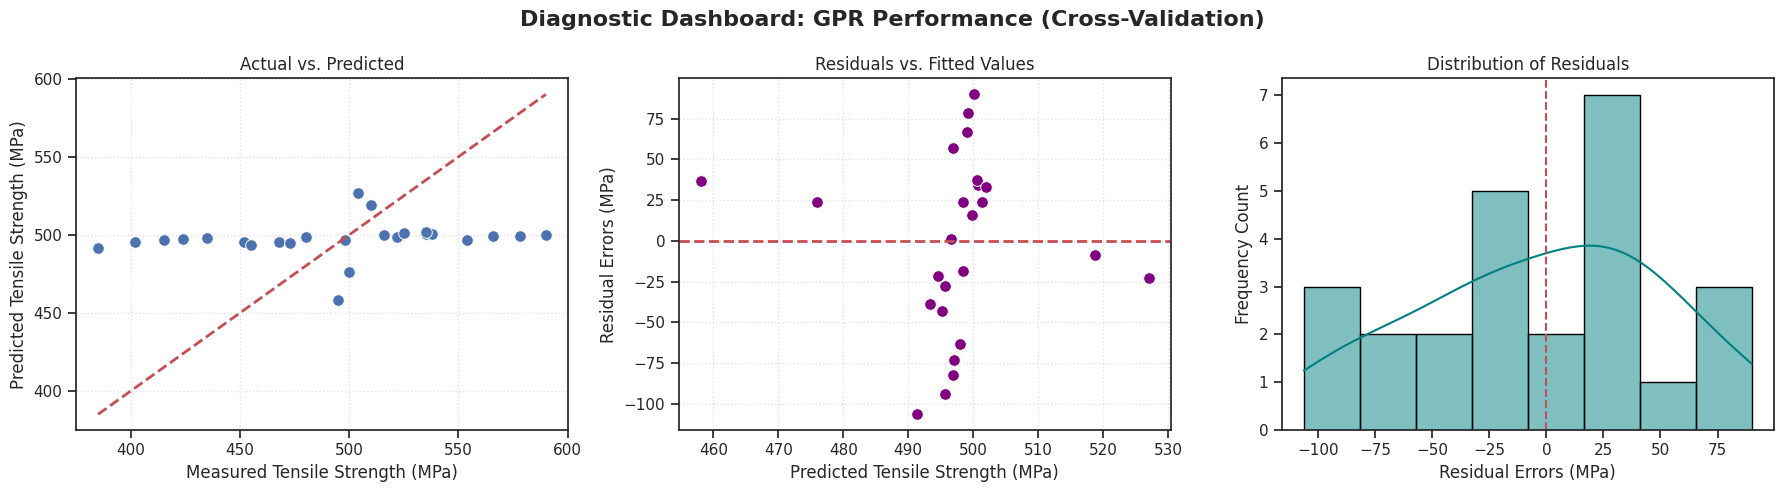

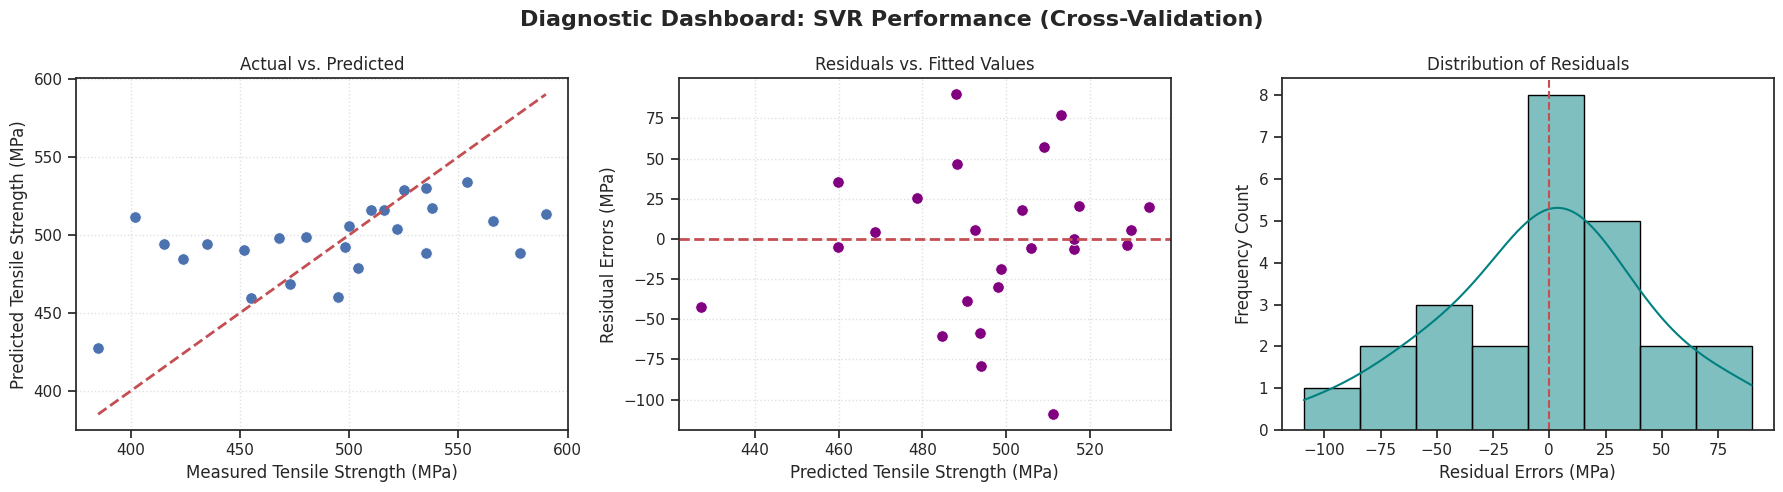

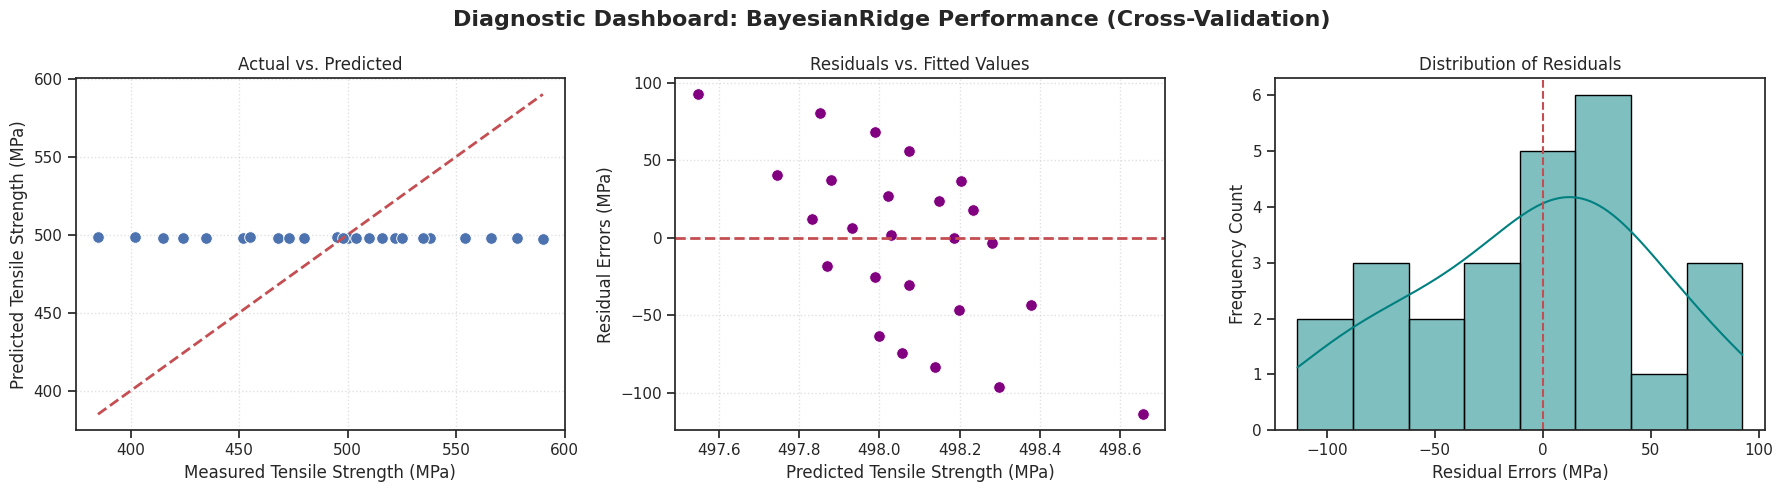

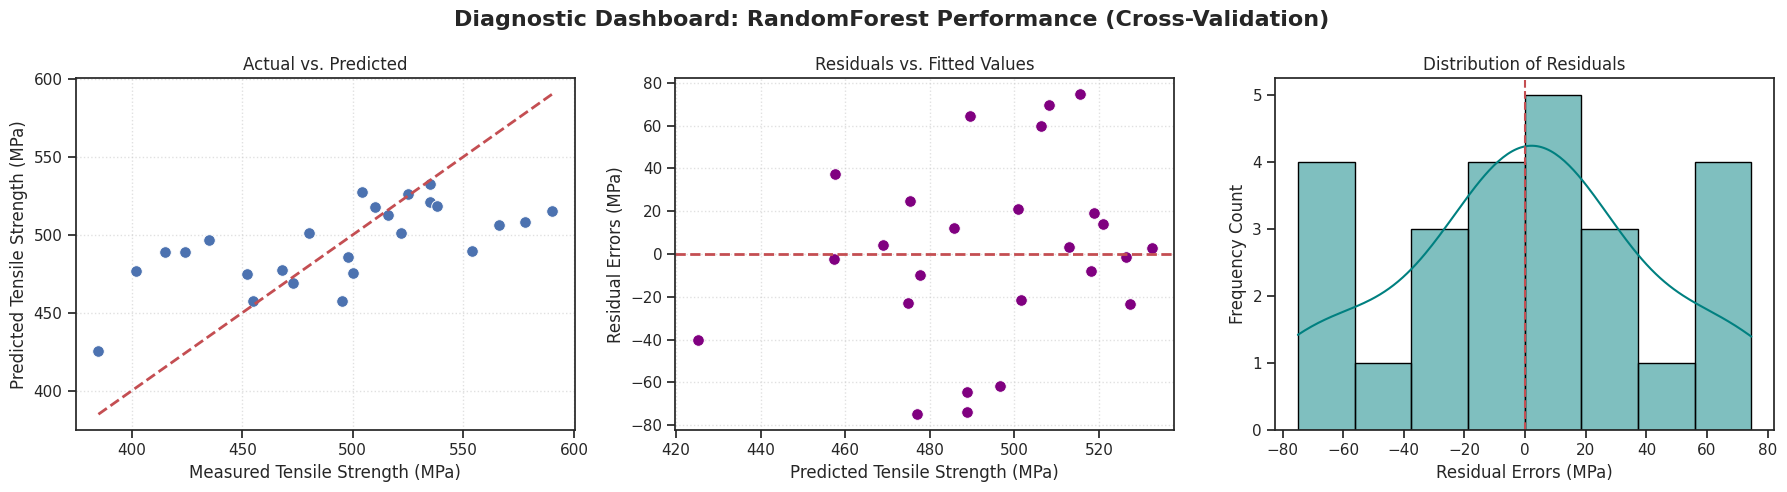

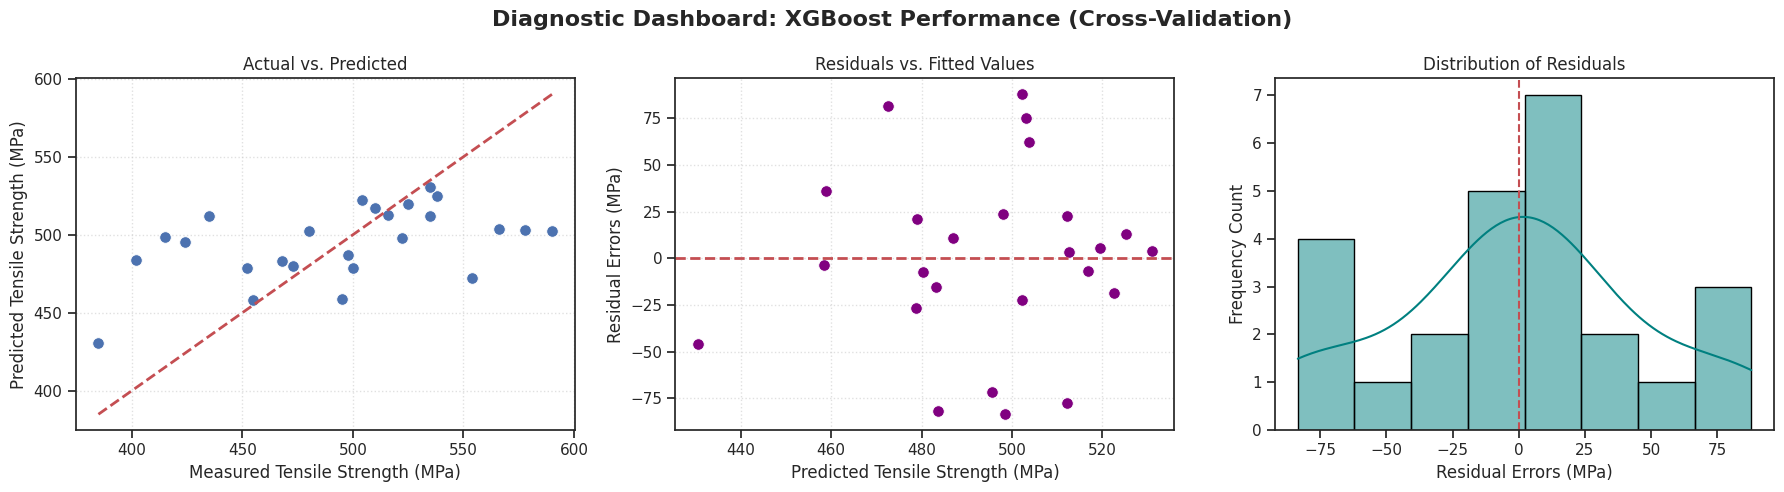


                 INTERACTIVE USER INFERENCE ENGINE            
Operational Ranges: Graphene (0.03-0.15), Al2O3 (0.1-0.18), Speed (600-1800), Depth (0.25-1.25)
-----------------------------------------------------------------


In [ ]:
# ==========================================
# 1. IMPORT ALL LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Preprocessing & Validation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge

# Interpolation
from scipy.interpolate import RBFInterpolator

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully.")

# ==========================================
# 2. ORIGINAL TAGUCHI DATA
# ==========================================
original = pd.DataFrame({
    'Exp': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'Graphene':[ 0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    'Al2O3': [ 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    'Speed': [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    'Depth': [0.25, 0.5, 0.75, 1, 1.25, 0.75, 1, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1, 0.5, 0.75, 1, 1.25, 0.25, 1, 1.25, 0.25, 0.5, 0.75],
    'Tensile_Strength':[385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
})

features = ['Graphene', 'Al2O3', 'Speed', 'Depth']
target = 'Tensile_Strength'

print(f"✓ Original Taguchi Data loaded. Shape: {original.shape}")

# ==========================================
# 3. GENERATE SYNTHETIC DATA GRID AND INTERPOLATE WITH RBF
# ==========================================
# Optimized resolution grid (~1,125 points) to ensure high resolution without exhausting Colab RAM
graphene_vals = np.linspace(0.03, 0.15, 5)
al2o3_vals    = np.linspace(0.10, 0.18, 5)
speed_vals    = np.arange(600, 1801, 150)
depth_vals    = np.linspace(0.25, 1.25, 5)

G, A, S, D = np.meshgrid(graphene_vals, al2o3_vals, speed_vals, depth_vals, indexing='ij')

synthetic = pd.DataFrame({
    'Graphene': G.ravel(),
    'Al2O3': A.ravel(),
    'Speed': S.ravel(),
    'Depth': D.ravel()
})

X_orig = original[features].values
y_orig = original[target].values
X_synth = synthetic[features].values

# Radial Basis Function interpolation
rbf = RBFInterpolator(X_orig, y_orig, kernel='multiquadric', epsilon=1.0, smoothing=0.1)
synthetic[target] = rbf(X_synth)

print(f"✓ Synthetic Data Grid generated via RBF interpolation. Shape: {synthetic.shape}")

# ==========================================
# 4. COMBINE ORIGINAL + SYNTHETIC DATA
# ==========================================
combined_data = pd.concat([original.drop(columns='Exp'), synthetic], ignore_index=True)
print(f"✓ Combined Dataset Created Successfully. Total Rows: {combined_data.shape[0]}")

# Pre-scaling vectors for stable machine learning operations
X = combined_data[features].values
Y = combined_data[[target]].values

scalerX = StandardScaler().fit(X)
scalerY = StandardScaler().fit(Y)

Xs = scalerX.transform(X)
Ys = scalerY.transform(Y).flatten()

# Initialize ML Architectures
gpr_kernel = C(1.0, (1e-3, 1e3)) * GPR_RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
models = {
    'GPR': GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=True, n_restarts_optimizer=5, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1),
    'BayesianRidge': BayesianRidge(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1)
}

# Run Leave-One-Out CV strictly across original positions to gather clean performance evaluations
loo = LeaveOneOut()
Xo_s = scalerX.transform(X_orig)
Yo_s = scalerY.transform(y_orig.reshape(-1, 1))

X_synth_s = scalerX.transform(X_synth)
Y_synth_s = scalerY.transform(synthetic[[target]].values)

cv_predictions = {m: [] for m in models}
cv_ground_truth = []

for train_idx, test_idx in loo.split(Xo_s):
    X_test = Xo_s[test_idx]
    cv_ground_truth.append(y_orig[test_idx][0])

    X_train = np.vstack([Xo_s[train_idx], X_synth_s])
    Y_train = np.vstack([Yo_s[train_idx], Y_synth_s]).flatten()

    for name, model in models.items():
        model.fit(X_train, Y_train)
        pred_s = model.predict(X_test)
        pred_actual = scalerY.inverse_transform(np.array(pred_s).reshape(-1, 1))[0][0]
        cv_predictions[name].append(pred_actual)

# Train production models on all data points
for name, model in models.items():
    model.fit(Xs, Ys)

# ==========================================
# 5. PRINT FIRST 10 ROWS OF ORIGINAL + SYNTHETIC WITH MODEL PREDICTIONS
# ==========================================
print("\n" + "="*80)
print("             FIRST 10 ROWS OF COMBINED DATASETS WITH ML PREDICTIONS")
print("="*80)
preview_df = combined_data.head(10).copy()
preview_scaled = scalerX.transform(preview_df[features].values)

for name, model in models.items():
    preds_scaled = model.predict(preview_scaled)
    preview_df[f'Pred_{name}'] = scalerY.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

display(preview_df.round(3))

# ==========================================
# 6. SUMMARY OF MODEL METRICS AND BEST MODEL BY MAE
# ==========================================
cv_summary_data = []
y_true_array = np.array(cv_ground_truth)

for name in models.keys():
    y_pred_array = np.array(cv_predictions[name])
    rmse_val = np.sqrt(mean_squared_error(y_true_array, y_pred_array))
    mae_val = mean_absolute_error(y_true_array, y_pred_array)
    r2_val = r2_score(y_true_array, y_pred_array)

    cv_summary_data.append({
        'Model': name,
        'RMSE (MPa)': rmse_val,
        'MAE (MPa)': mae_val,
        'R2 Score': r2_val
    })

summary_df = pd.DataFrame(cv_summary_data)
best_model_name = summary_df.loc[summary_df['MAE (MPa)'].idxmin()]['Model']

print("\n" + "="*50)
print("          LEAVE-ONE-OUT CV PERFORMANCE PROFILE")
print("="*50)
display(summary_df.round(4))
print(f"🥇 Best Architecture (Lowest MAE): **{best_model_name}**")

# ==========================================
# 8. SAVE RESULTS TO CSV
# ==========================================
# Generate full dataset predictions for downstream use/auditing
full_output_df = combined_data.copy()
for name, model in models.items():
    full_output_df[f'Predicted_TS_{name}'] = scalerY.inverse_transform(model.predict(Xs).reshape(-1, 1)).flatten()

csv_filename = 'taguchi_synthetic_ml_predictions.csv'
full_output_df.to_csv(csv_filename, index=False)
print(f"\n✓ Complete dataset with predictions saved locally to: `{csv_filename}`")

# ==========================================
# 9 & 10. PLOTS: ACTUAL VS PREDICTED & RESIDUAL ANALYSIS
# ==========================================
sns.set_theme(style="ticks")
y_true = np.array(cv_ground_truth)

for name in models.keys():
    y_pred = np.array(cv_predictions[name])
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Diagnostic Dashboard: {name} Performance (Cross-Validation)', fontsize=16, fontweight='bold')

    # 9. Actual vs Predicted Scatter Plot
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0], color='b', edgecolor='w', s=70)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_title('Actual vs. Predicted')
    axes[0].set_xlabel('Measured Tensile Strength (MPa)')
    axes[0].set_ylabel('Predicted Tensile Strength (MPa)')
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # 10a. Residual Scatter Plot
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='purple', edgecolor='w', s=70)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Residuals vs. Fitted Values')
    axes[1].set_xlabel('Predicted Tensile Strength (MPa)')
    axes[1].set_ylabel('Residual Errors (MPa)')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # 10b. Residual Histogram
    sns.histplot(residuals, kde=True, ax=axes[2], color='teal', bins=8, edgecolor='black')
    axes[2].axvline(x=0, color='r', linestyle='--', lw=1.5)
    axes[2].set_title('Distribution of Residuals')
    axes[2].set_xlabel('Residual Errors (MPa)')
    axes[2].set_ylabel('Frequency Count')

    plt.tight_layout()
    plt.show()

# ==========================================
# 7. INTERACTIVE USER PREDICTION (RUN AT END)
# ==========================================
print("\n" + "="*65)
print("                 INTERACTIVE USER INFERENCE ENGINE            ")
print("="*65)
print(f"Operational Ranges: Graphene ({X_orig[:,0].min()}-{X_orig[:,0].max()}), "
      f"Al2O3 ({X_orig[:,1].min()}-{X_orig[:,1].max()}), "
      f"Speed ({int(X_orig[:,2].min())}-{int(X_orig[:,2].max())}), "
      f"Depth ({X_orig[:,3].min()}-{X_orig[:,3].max()})")
print("-"*65)

try:
    u_graph  = float(input("Enter Graphene content: ") or 0.08)
    u_al2o3  = float(input("Enter Al2O3 content: ") or 0.15)
    u_speed  = float(input("Enter Cutting Speed: ") or 1350)
    u_depth  = float(input("Enter Cut Depth: ") or 0.65)

    user_inputs = pd.DataFrame([[u_graph, u_al2o3, u_speed, u_depth]], columns=features)
    user_scaled = scalerX.transform(user_inputs.values)

    print("\n" + "-" * 65)
    print(f"{'Machine Learning Model Architecture':<35} | {'Predicted Tensile Strength':<25}")
    print("-" * 65)

    for name, model in models.items():
        p_scale = model.predict(user_scaled)
        p_actual = scalerY.inverse_transform(p_scale.reshape(-1, 1))[0][0]
        marker = "⭐" if name == best_model_name else "  "
        print(f"{marker} {name:<33} | {p_actual:<25.3f} MPa")
    print("=" * 65)

except Exception as e:
    print(f"\n⚠️ Inference parsing halted: {e}. Please ensure input parameters remain numbers.")

In [ ]:
import warnings
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import RBF as GPR_RBF
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

# ==========================================
# 1. Load Original Dataset
# ==========================================
df_orig = pd.DataFrame(
    {
        "Exp": list(range(1, 26)),
        "Graphene": [
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
            0.1,
            0.1,
            0.1,
            0.1,
            0.1,
            0.15,
            0.03,
            0.03,
            0.03,
            0.04,
            0.04,
            0.04,
            0.04,
            0.04,
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
        ],
        "Al2O3": [
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
        ],
        "Speed": [
            600,
            900,
            1200,
            1500,
            1800,
            900,
            1200,
            1500,
            1800,
            600,
            1200,
            1500,
            1800,
            600,
            900,
            1500,
            1800,
            600,
            900,
            1200,
            1800,
            600,
            900,
            1200,
            1500,
        ],
        "Depth": [
            0.25,
            0.5,
            0.75,
            1,
            1.25,
            0.75,
            1,
            1.25,
            0.25,
            0.5,
            1.25,
            0.25,
            0.75,
            0.5,
            1,
            0.5,
            0.75,
            1,
            1.25,
            0.25,
            1,
            1.25,
            0.25,
            0.5,
            0.75,
        ],
        "Tensile_Strength": [
            385,
            402,
            415,
            424,
            435,
            452,
            468,
            473,
            480,
            455,
            500,
            504,
            510,
            495,
            498,
            535,
            538,
            516,
            522,
            525,
            590,
            535,
            554,
            566,
            578,
        ],
    }
)

input_cols = ["Graphene", "Al2O3", "Speed", "Depth"]
target_col = "Tensile_Strength"

# ==========================================
# 2. Generate Synthetic Data Grid (RBF Interpolation)
# ==========================================
# Using reasonable step sizes across ranges to avoid huge memory/terminal strain
graphene_vals = np.linspace(
    df_orig["Graphene"].min(), df_orig["Graphene"].max(), 5
)
al2o3_vals = np.linspace(df_orig["Al2O3"].min(), df_orig["Al2O3"].max(), 5)
speed_vals = np.linspace(df_orig["Speed"].min(), df_orig["Speed"].max(), 5)
depth_vals = np.linspace(df_orig["Depth"].min(), df_orig["Depth"].max(), 5)

G, A, S, D = np.meshgrid(
    graphene_vals, al2o3_vals, speed_vals, depth_vals, indexing="ij"
)

synthetic_df = pd.DataFrame(
    {
        "Graphene": G.ravel(),
        "Al2O3": A.ravel(),
        "Speed": S.ravel(),
        "Depth": D.ravel(),
    }
)

# Scale features internally for stable RBFInterpolation across varying feature dimensions
rbf_scaler = StandardScaler()
X_orig_scaled_rbf = rbf_scaler.fit_transform(df_orig[input_cols].values)
X_synth_scaled_rbf = rbf_scaler.transform(synthetic_df[input_cols].values)

rbf_interp = RBFInterpolator(
    X_orig_scaled_rbf,
    df_orig[target_col].values,
    kernel="multiquadric",
    epsilon=1.0,
    smoothing=0.1,
)
synthetic_df[target_col] = rbf_interp(X_synth_scaled_rbf)

# ==========================================
# 3. Combine Original + Synthetic Data for Scaling
# ==========================================
data_all = pd.concat([df_orig, synthetic_df], ignore_index=True)

scalerX = StandardScaler().fit(data_all[input_cols].values)
df_orig_scaled = scalerX.transform(df_orig[input_cols].values)
synthetic_scaled = scalerX.transform(synthetic_df[input_cols].values)
X_train_scaled = np.vstack([df_orig_scaled, synthetic_scaled])

scalerY = StandardScaler().fit(data_all[[target_col]].values)
y_all_scaled = scalerY.transform(data_all[[target_col]].values).flatten()

# ==========================================
# 4. Train Models & Predict
# ==========================================
gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
models = {
    "GPR": GaussianProcessRegressor(
        kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
    "BayesianRidge": BayesianRidge(),
}

model_results = {}
fitted_models = {}

print(f"\n--- Model Evaluation for {target_col} ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_all_scaled)
    fitted_models[name] = model

    # Predict Original Data
    y_pred_orig_scaled = model.predict(df_orig_scaled)
    y_pred_orig = scalerY.inverse_transform(
        y_pred_orig_scaled.reshape(-1, 1)
    ).flatten()

    # Predict Synthetic Data
    y_pred_synth_scaled = model.predict(synthetic_scaled)
    y_pred_synth = scalerY.inverse_transform(
        y_pred_synth_scaled.reshape(-1, 1)
    ).flatten()

    # Percentage Error Calculation
    perc_err_synth = (
        (synthetic_df[target_col].values - y_pred_synth)
        / synthetic_df[target_col].values
        * 100
    )
    synthetic_df[f"{target_col}_{name}_err"] = perc_err_synth.round(2)

    # Metrics on Original Data
    mae = mean_absolute_error(df_orig[target_col].values, y_pred_orig)
    rmse = np.sqrt(
        mean_squared_error(df_orig[target_col].values, y_pred_orig)
    )
    r2 = r2_score(df_orig[target_col].values, y_pred_orig)

    model_results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

    # Store predictions in DataFrames
    df_orig[f"{target_col}_{name}"] = y_pred_orig
    df_orig[f"{target_col}_{name}_err"] = (
        (df_orig[target_col].values - y_pred_orig)
        / df_orig[target_col].values
        * 100
    ).round(2)
    synthetic_df[f"{target_col}_{name}"] = y_pred_synth

# ==========================================
# 5. Print Data Summaries (Truncation Protection)
# ==========================================
# Printing first 10 rows of synthetic predictions to prevent terminal truncation buffer errors
for name in ["GPR", "SVR", "BayesianRidge"]:
    print(
        f"\nSynthetic predictions sample (First 10 rows) for {target_col} using {name}:"
    )
    cols = [
        "Graphene",
        "Al2O3",
        "Speed",
        "Depth",
        target_col,
        f"{target_col}_{name}",
        f"{target_col}_{name}_err",
    ]
    print(synthetic_df[cols].head(10).to_string(index=False))

# Print all 25 original points as they are compact
for name in ["GPR", "SVR", "BayesianRidge"]:
    print(f"\nOriginal predictions for {target_col} using {name}:")
    cols = [
        "Graphene",
        "Al2O3",
        "Speed",
        "Depth",
        target_col,
        f"{target_col}_{name}",
        f"{target_col}_{name}_err",
    ]
    print(df_orig[cols].to_string(index=False))

# ==========================================
# 6. Performance Summary
# ==========================================
print("\n=== MODEL PERFORMANCE SUMMARY (MAE, RMSE, R²) ===")
best_mae_model = min(model_results, key=lambda k: model_results[k]["MAE"])
for model_name, res in model_results.items():
    print(
        f"{model_name:>14}: MAE={res['MAE']:.2f}, RMSE={res['RMSE']:.2f}, R²={res['R2']:.3f}"
    )
print(f"Best Performing Model (by MAE): {best_mae_model}")

# ==========================================
# 7. Interactive User Prediction
# ==========================================
print("\n=== Interactive Prediction for New Inputs ===")
try:
    graphene = float(input("Graphene content (e.g. 0.05): "))
    al2o3 = float(input("Al2O3 content (e.g. 0.12): "))
    speed = float(input("Speed (e.g. 1200): "))
    depth = float(input("Depth (e.g. 0.5): "))
except Exception:
    graphene, al2o3, speed, depth = 0.05, 0.12, 1200, 0.5
    print(
        f"Using default parameters: Graphene={graphene}, Al2O3={al2o3}, Speed={speed}, Depth={depth}"
    )

user_X_scaled = scalerX.transform([[graphene, al2o3, speed, depth]])
best_model = fitted_models[best_mae_model]

y_user_pred_scaled = best_model.predict(user_X_scaled)
y_user_pred = scalerY.inverse_transform(
    np.array(y_user_pred_scaled).reshape(-1, 1)
).flatten()[0]

print(
    f"\nPredicted Tensile Strength using best model ({best_mae_model}): {y_user_pred:.2f} MPa"
)

# ==========================================
# 8. Export Full Datasets to CSV
# ==========================================
df_orig.to_csv("taguchi_original_with_predictions.csv", index=False)
synthetic_df.to_csv("taguchi_synthetic_with_predictions.csv", index=False)
print("\n✓ Full predictions saved to CSV files.")


--- Model Evaluation for Tensile_Strength ---
GPR: MAE=0.27, RMSE=0.88, R²=1.000
SVR: MAE=9.23, RMSE=13.62, R²=0.936
BayesianRidge: MAE=41.17, RMSE=51.25, R²=0.095

Synthetic predictions sample (First 10 rows) for Tensile_Strength using GPR:
 Graphene  Al2O3  Speed  Depth  Tensile_Strength  Tensile_Strength_GPR  Tensile_Strength_GPR_err
     0.03    0.1  600.0   0.25        409.443832            409.443832                      -0.0
     0.03    0.1  600.0   0.50        412.566037            412.566037                      -0.0
     0.03    0.1  600.0   0.75        443.670116            443.670116                      -0.0
     0.03    0.1  600.0   1.00        491.005128            491.005128                       0.0
     0.03    0.1  600.0   1.25        533.310725            533.310725                       0.0
     0.03    0.1  900.0   0.25        433.510327            433.510327                      -0.0
     0.03    0.1  900.0   0.50        428.775051            428.775051        


--- Model Evaluation for Tensile_Strength ---
           GPR: MAE=0.27, RMSE=0.88, R²=1.000
           SVR: MAE=9.23, RMSE=13.62, R²=0.936
 BayesianRidge: MAE=41.17, RMSE=51.25, R²=0.095

Generating model evaluation plots...


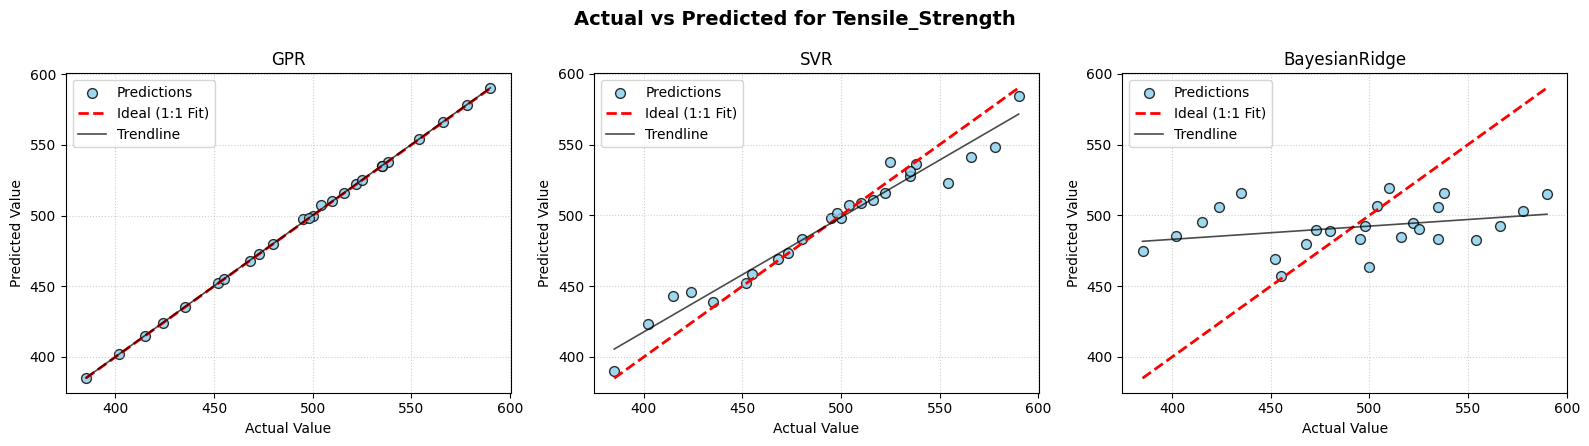

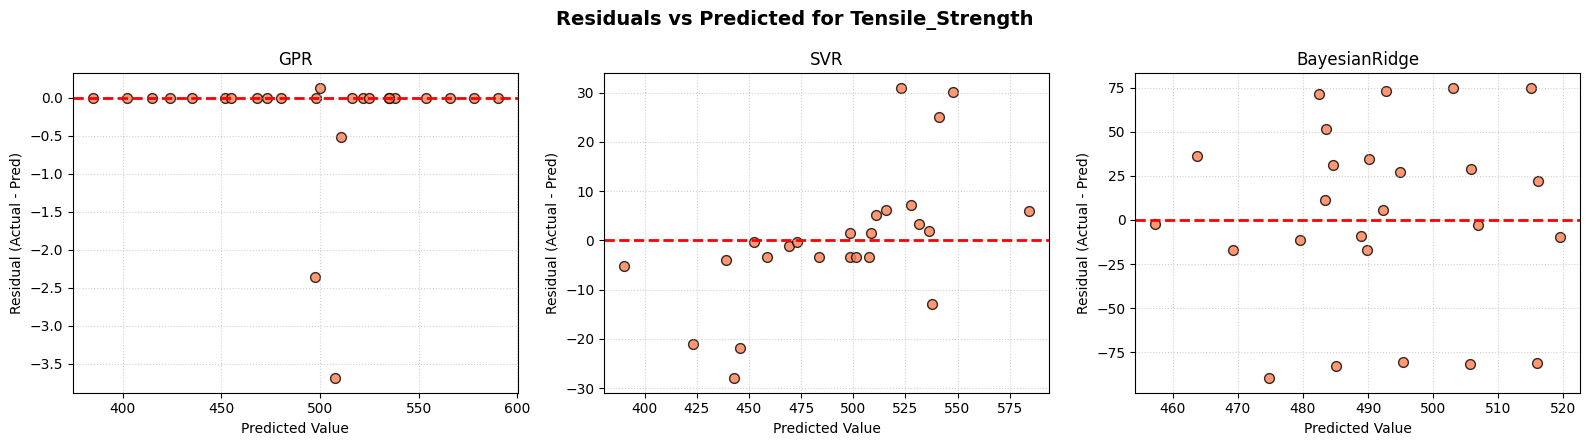

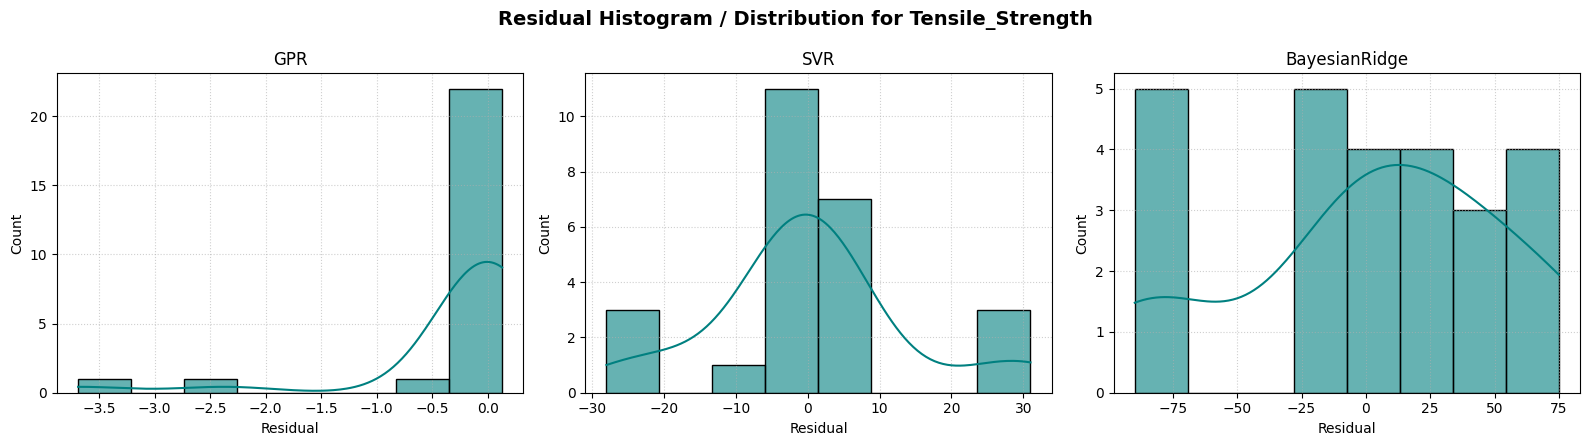

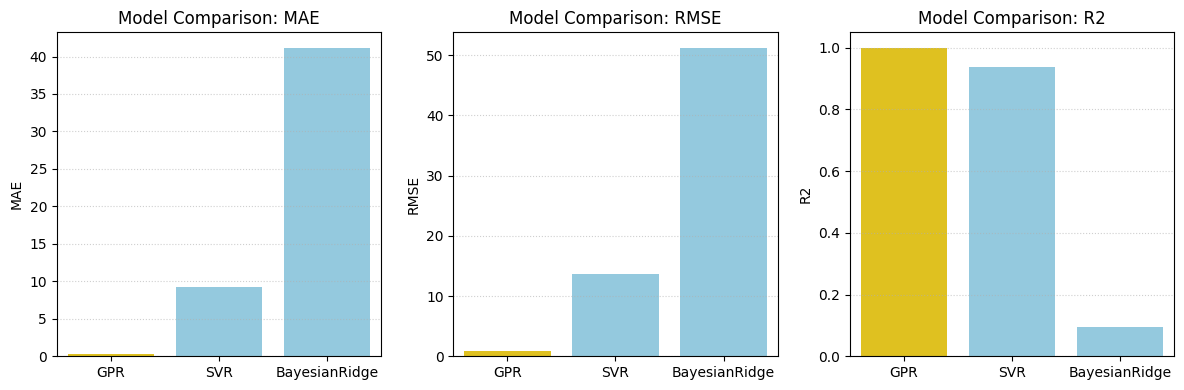

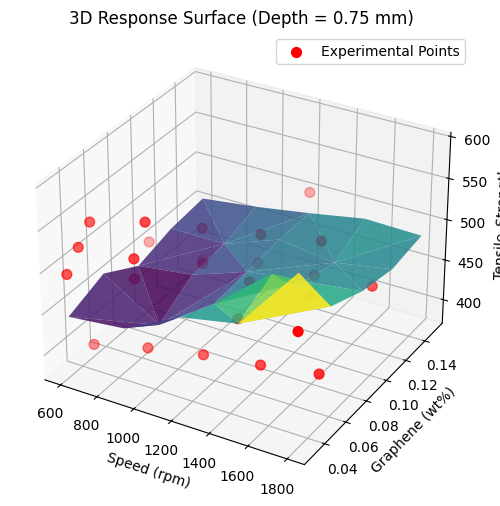

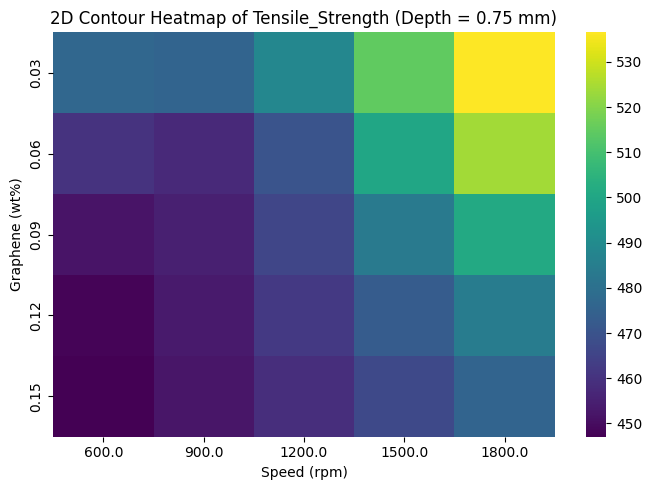

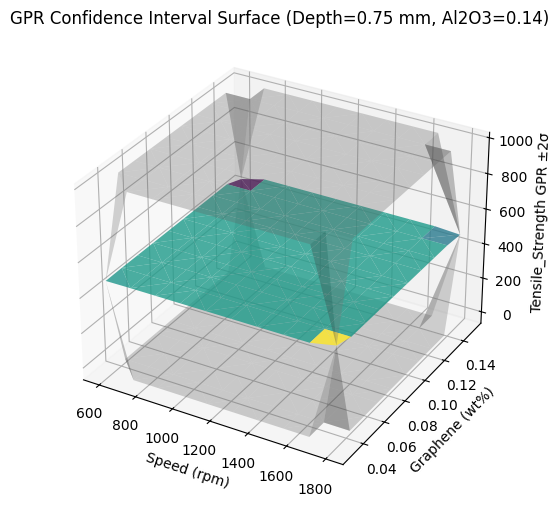

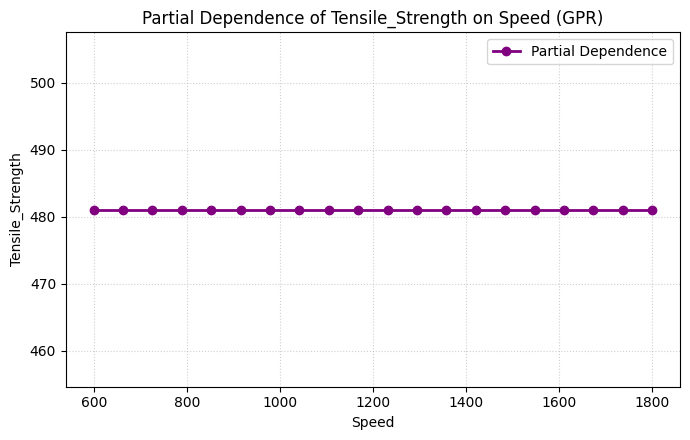

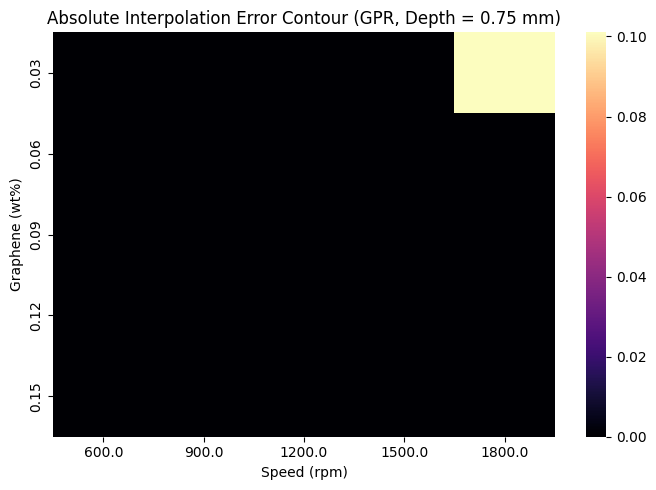

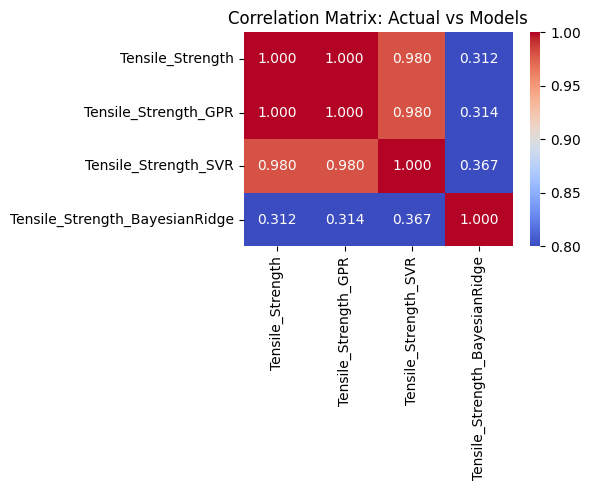

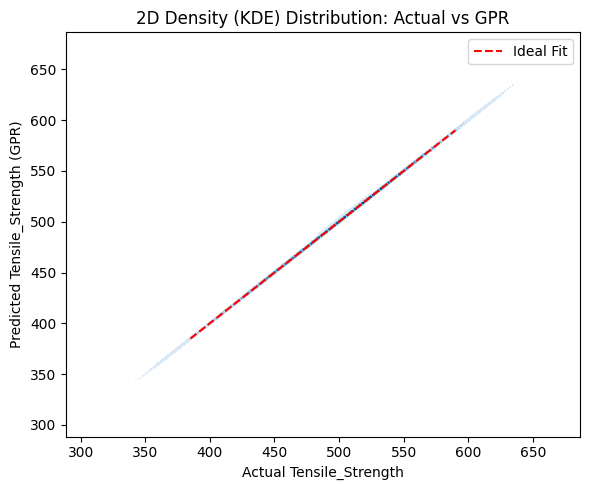

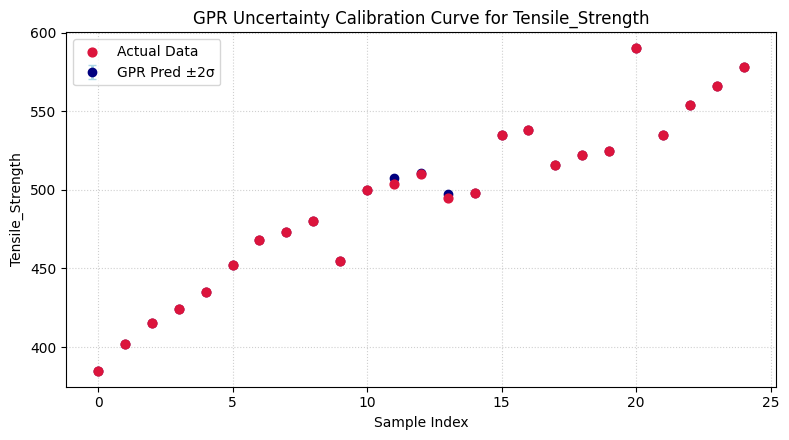

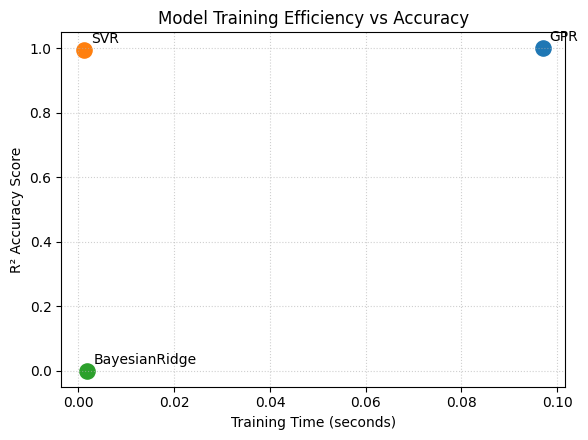

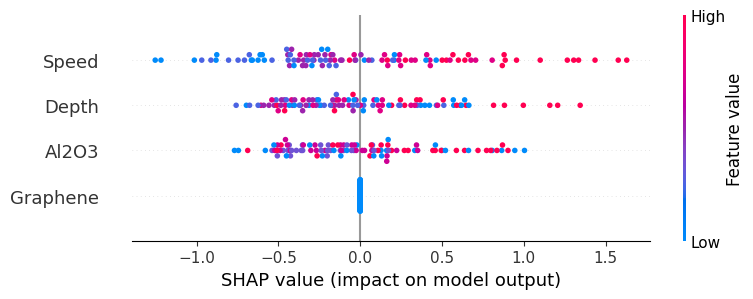


=== Interactive Prediction for Composite Material Properties ===
Graphene content (wt%) [0.03 - 0.15]: 0.04


In [ ]:
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import RBF as GPR_RBF
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

# Optional SHAP import for model explainability
try:
    import shap

    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Notice: 'shap' package not installed. Skipping SHAP summary plots.")

# ==========================================
# 1. Load Original Dataset
# ==========================================
df_orig = pd.DataFrame(
    {
        "Exp": list(range(1, 26)),
        "Graphene": [
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
            0.1,
            0.1,
            0.1,
            0.1,
            0.1,
            0.15,
            0.03,
            0.03,
            0.03,
            0.04,
            0.04,
            0.04,
            0.04,
            0.04,
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
            0.05,
        ],
        "Al2O3": [
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
            0.1,
            0.12,
            0.14,
            0.16,
            0.18,
        ],
        "Speed": [
            600,
            900,
            1200,
            1500,
            1800,
            900,
            1200,
            1500,
            1800,
            600,
            1200,
            1500,
            1800,
            600,
            900,
            1500,
            1800,
            600,
            900,
            1200,
            1800,
            600,
            900,
            1200,
            1500,
        ],
        "Depth": [
            0.25,
            0.5,
            0.75,
            1,
            1.25,
            0.75,
            1,
            1.25,
            0.25,
            0.5,
            1.25,
            0.25,
            0.75,
            0.5,
            1,
            0.5,
            0.75,
            1,
            1.25,
            0.25,
            1,
            1.25,
            0.25,
            0.5,
            0.75,
        ],
        "Tensile_Strength": [
            385,
            402,
            415,
            424,
            435,
            452,
            468,
            473,
            480,
            455,
            500,
            504,
            510,
            495,
            498,
            535,
            538,
            516,
            522,
            525,
            590,
            535,
            554,
            566,
            578,
        ],
    }
)

input_cols = ["Graphene", "Al2O3", "Speed", "Depth"]
target_col = "Tensile_Strength"

# ==========================================
# 2. Generate Synthetic Grid Data (RBF Interpolation)
# ==========================================
# Generate 5 resolution points per feature -> 5^4 = 625 synthetic points
GRID_DENSITY = 5
graphene_vals = np.linspace(
    df_orig["Graphene"].min(), df_orig["Graphene"].max(), GRID_DENSITY
)
al2o3_vals = np.linspace(
    df_orig["Al2O3"].min(), df_orig["Al2O3"].max(), GRID_DENSITY
)
speed_vals = np.linspace(
    df_orig["Speed"].min(), df_orig["Speed"].max(), GRID_DENSITY
)
depth_vals = np.linspace(
    df_orig["Depth"].min(), df_orig["Depth"].max(), GRID_DENSITY
)

G, A, S, D = np.meshgrid(
    graphene_vals, al2o3_vals, speed_vals, depth_vals, indexing="ij"
)

synthetic_df = pd.DataFrame(
    {
        "Graphene": G.ravel(),
        "Al2O3": A.ravel(),
        "Speed": S.ravel(),
        "Depth": D.ravel(),
    }
)

# RBF Interpolator with internal scaling for feature uniformity
rbf_scaler = StandardScaler()
X_orig_scaled_rbf = rbf_scaler.fit_transform(df_orig[input_cols].values)
X_synth_scaled_rbf = rbf_scaler.transform(synthetic_df[input_cols].values)

rbf_interp = RBFInterpolator(
    X_orig_scaled_rbf,
    df_orig[target_col].values,
    kernel="multiquadric",
    epsilon=1.0,
    smoothing=0.1,
)
synthetic_df[target_col] = rbf_interp(X_synth_scaled_rbf)

# ==========================================
# 3. Combine & Scale Features / Target
# ==========================================
data_all = pd.concat([df_orig, synthetic_df], ignore_index=True)

scalerX = StandardScaler().fit(data_all[input_cols].values)
df_orig_scaled = scalerX.transform(df_orig[input_cols].values)
synthetic_scaled = scalerX.transform(synthetic_df[input_cols].values)
X_train_scaled = np.vstack([df_orig_scaled, synthetic_scaled])

scalerY = StandardScaler().fit(data_all[[target_col]].values)
y_all_scaled = scalerY.transform(data_all[[target_col]].values).flatten()

# ==========================================
# 4. Fit Machine Learning Models & Predict
# ==========================================
gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
models = {
    "GPR": GaussianProcessRegressor(
        kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
    "BayesianRidge": BayesianRidge(),
}

model_results = {}
fitted_models = {}

print(f"\n--- Model Evaluation for {target_col} ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_all_scaled)
    fitted_models[name] = model

    # Predict Original Data
    y_pred_orig_scaled = model.predict(df_orig_scaled)
    y_pred_orig = scalerY.inverse_transform(
        y_pred_orig_scaled.reshape(-1, 1)
    ).flatten()

    # Predict Synthetic Data
    y_pred_synth_scaled = model.predict(synthetic_scaled)
    y_pred_synth = scalerY.inverse_transform(
        y_pred_synth_scaled.reshape(-1, 1)
    ).flatten()

    # Save outputs & percentage errors
    df_orig[f"{target_col}_{name}"] = y_pred_orig
    df_orig[f"{target_col}_{name}_err"] = (
        (df_orig[target_col].values - y_pred_orig)
        / df_orig[target_col].values
        * 100
    ).round(2)

    synthetic_df[f"{target_col}_{name}"] = y_pred_synth
    synthetic_df[f"{target_col}_{name}_err"] = (
        (synthetic_df[target_col].values - y_pred_synth)
        / synthetic_df[target_col].values
        * 100
    ).round(2)

    # Performance Metrics (Evaluated on original observations)
    mae = mean_absolute_error(df_orig[target_col].values, y_pred_orig)
    rmse = np.sqrt(
        mean_squared_error(df_orig[target_col].values, y_pred_orig)
    )
    r2 = r2_score(df_orig[target_col].values, y_pred_orig)

    model_results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:>14}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

# Find overall best model
best_mae_model = min(model_results, key=lambda k: model_results[k]["MAE"])

# ==========================================
# 5. ALL DIAGNOSTIC & ANALYTICAL PLOTS
# ==========================================


def plot_actual_vs_predicted(df, outvar, model_names):
    plt.figure(figsize=(16, 4.5))
    plt.suptitle(f"Actual vs Predicted for {outvar}", fontsize=14, fontweight="bold")
    for i, name in enumerate(model_names):
        plt.subplot(1, len(model_names), i + 1)
        plt.scatter(
            df[outvar],
            df[f"{outvar}_{name}"],
            color="skyblue",
            edgecolor="k",
            alpha=0.8,
            s=50,
            label="Predictions",
        )
        minval, maxval = df[outvar].min(), df[outvar].max()
        plt.plot(
            [minval, maxval],
            [minval, maxval],
            "r--",
            lw=2,
            label="Ideal (1:1 Fit)",
        )

        z = np.polyfit(df[outvar], df[f"{outvar}_{name}"], 1)
        p = np.poly1d(z)
        plt.plot(
            sorted(df[outvar]),
            p(sorted(df[outvar])),
            "k-",
            lw=1.2,
            alpha=0.7,
            label="Trendline",
        )

        plt.xlabel("Actual Value")
        plt.ylabel("Predicted Value")
        plt.title(f"{name}")
        plt.legend()
        plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_residuals_vs_predicted(df, outvar, model_names):
    plt.figure(figsize=(16, 4.5))
    plt.suptitle(
        f"Residuals vs Predicted for {outvar}", fontsize=14, fontweight="bold"
    )
    for i, name in enumerate(model_names):
        plt.subplot(1, len(model_names), i + 1)
        resids = df[outvar] - df[f"{outvar}_{name}"]
        plt.scatter(
            df[f"{outvar}_{name}"],
            resids,
            color="coral",
            alpha=0.8,
            edgecolor="k",
            s=50,
        )
        plt.axhline(0, color="r", linestyle="--", lw=2)
        plt.xlabel("Predicted Value")
        plt.ylabel("Residual (Actual - Pred)")
        plt.title(f"{name}")
        plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_residual_hist(df, outvar, model_names):
    plt.figure(figsize=(16, 4.5))
    plt.suptitle(
        f"Residual Histogram / Distribution for {outvar}",
        fontsize=14,
        fontweight="bold",
    )
    for i, name in enumerate(model_names):
        plt.subplot(1, len(model_names), i + 1)
        resids = df[outvar] - df[f"{outvar}_{name}"]
        sns.histplot(resids, kde=True, bins=8, color="teal", alpha=0.6)
        plt.xlabel("Residual")
        plt.title(f"{name}")
        plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_cv_metrics(results):
    metrics = ["MAE", "RMSE", "R2"]
    plt.figure(figsize=(12, 4))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        labels = list(results.keys())
        vals = [results[m][metric] for m in labels]
        palette = [
            "gold" if m == best_mae_model else "skyblue" for m in labels
        ]
        sns.barplot(x=labels, y=vals, palette=palette)
        plt.title(f"Model Comparison: {metric}")
        plt.ylabel(metric)
        plt.grid(True, axis="y", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_3d_response_surface(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)]
    if len(sub) < 3:
        return
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_trisurf(
        sub["Speed"],
        sub["Graphene"],
        sub[f"{outvar}_GPR"],
        cmap="viridis",
        alpha=0.85,
    )
    ax.scatter(
        df_orig["Speed"],
        df_orig["Graphene"],
        df_orig[outvar],
        color="red",
        s=50,
        label="Experimental Points",
    )
    ax.set_xlabel("Speed (rpm)")
    ax.set_ylabel("Graphene (wt%)")
    ax.set_zlabel(outvar)
    plt.title(f"3D Response Surface (Depth = {fixed_depth} mm)")
    plt.legend()
    plt.show()


def plot_2d_contour(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)]
    if len(sub) < 3:
        return
    pivot = sub.pivot_table(
        index="Graphene", columns="Speed", values=f"{outvar}_GPR"
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(pivot, cmap="viridis", annot=False)
    plt.title(f"2D Contour Heatmap of {outvar} (Depth = {fixed_depth} mm)")
    plt.xlabel("Speed (rpm)")
    plt.ylabel("Graphene (wt%)")
    plt.tight_layout()
    plt.show()


def plot_gpr_uncertainty_surface(
    models_dict, outvar, scalerX, scalerY, fixed_depth=0.75
):
    gpr = models_dict["GPR"]
    speeds = np.linspace(df_orig["Speed"].min(), df_orig["Speed"].max(), 10)
    graphenes = np.linspace(
        df_orig["Graphene"].min(), df_orig["Graphene"].max(), 10
    )
    grid = np.array(
        [[g, 0.14, s, fixed_depth] for s in speeds for g in graphenes]
    )

    grid_scaled = scalerX.transform(grid)
    mean, std = gpr.predict(grid_scaled, return_std=True)
    mean = scalerY.inverse_transform(mean.reshape(-1, 1)).flatten()

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    X_grid = grid[:, 2]  # Speed
    Y_grid = grid[:, 0]  # Graphene

    ax.plot_trisurf(X_grid, Y_grid, mean, cmap="viridis", alpha=0.8)
    ax.plot_trisurf(X_grid, Y_grid, mean + 2 * std, color="gray", alpha=0.3)
    ax.plot_trisurf(X_grid, Y_grid, mean - 2 * std, color="gray", alpha=0.3)
    ax.set_xlabel("Speed (rpm)")
    ax.set_ylabel("Graphene (wt%)")
    ax.set_zlabel(f"{outvar} GPR ±2σ")
    plt.title(
        f"GPR Confidence Interval Surface (Depth={fixed_depth} mm, Al2O3=0.14)"
    )
    plt.show()


def plot_ice_partial_dependence(
    models_dict, scalerX, scalerY, outvar, feature_name="Speed"
):
    model = models_dict["GPR"]
    feat_idx = input_cols.index(feature_name)
    feature_range = np.linspace(
        df_orig[feature_name].min(), df_orig[feature_name].max(), 20
    )

    fixed_vals = [0.05, 0.14, 1200, 0.75]  # Nominal baseline
    X_base = np.array([fixed_vals for _ in feature_range])
    for i, val in enumerate(feature_range):
        X_base[i][feat_idx] = val

    X_base_scaled = scalerX.transform(X_base)
    preds = scalerY.inverse_transform(
        model.predict(X_base_scaled).reshape(-1, 1)
    ).flatten()

    plt.figure(figsize=(7, 4.5))
    plt.plot(
        feature_range,
        preds,
        marker="o",
        color="purple",
        lw=2,
        label="Partial Dependence",
    )
    plt.xlabel(feature_name)
    plt.ylabel(outvar)
    plt.title(f"Partial Dependence of {outvar} on {feature_name} (GPR)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_error_contour(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)].copy()
    if len(sub) < 3:
        return
    sub["abs_err"] = np.abs(sub[outvar] - sub[f"{outvar}_GPR"])
    pivot = pd.pivot_table(
        sub, index="Graphene", columns="Speed", values="abs_err"
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(pivot, cmap="magma", annot=False)
    plt.title(
        f"Absolute Interpolation Error Contour (GPR, Depth = {fixed_depth} mm)"
    )
    plt.xlabel("Speed (rpm)")
    plt.ylabel("Graphene (wt%)")
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, outvar, model_names):
    cols_to_corr = [outvar] + [f"{outvar}_{m}" for m in model_names]
    corr = df[cols_to_corr].corr()

    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=0.8, vmax=1.0)
    plt.title("Correlation Matrix: Actual vs Models")
    plt.tight_layout()
    plt.show()


def plot_2d_kde(df, outvar, model_name="GPR"):
    plt.figure(figsize=(6, 5))
    sns.kdeplot(
        x=df[outvar],
        y=df[f"{outvar}_{model_name}"],
        fill=True,
        cmap="Blues",
        thresh=0.05,
    )
    plt.plot(
        [df[outvar].min(), df[outvar].max()],
        [df[outvar].min(), df[outvar].max()],
        "r--",
        label="Ideal Fit",
    )
    plt.xlabel(f"Actual {outvar}")
    plt.ylabel(f"Predicted {outvar} ({model_name})")
    plt.title(f"2D Density (KDE) Distribution: Actual vs {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_calibration_curve(models_dict, scalerX, scalerY, outvar, df):
    gpr = models_dict["GPR"]
    X = scalerX.transform(df[input_cols].values)
    y_true = df[outvar].values

    mean, std = gpr.predict(X, return_std=True)
    mean = scalerY.inverse_transform(mean.reshape(-1, 1)).flatten()

    plt.figure(figsize=(8, 4.5))
    plt.errorbar(
        np.arange(len(y_true)),
        mean,
        yerr=2 * std,
        fmt="o",
        color="navy",
        ecolor="lightblue",
        elinewidth=2,
        capsize=3,
        label="GPR Pred ±2σ",
    )
    plt.scatter(
        np.arange(len(y_true)),
        y_true,
        color="crimson",
        zorder=5,
        s=40,
        label="Actual Data",
    )
    plt.xlabel("Sample Index")
    plt.ylabel(outvar)
    plt.title(f"GPR Uncertainty Calibration Curve for {outvar}")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_time_vs_accuracy(df):
    times = []
    scores = []
    names = ["GPR", "SVR", "BayesianRidge"]

    X = scalerX.transform(df[input_cols].values)
    y = scalerY.transform(df[[target_col]].values).flatten()

    test_models = {
        "GPR": GaussianProcessRegressor(
            kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2
        ),
        "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
        "BayesianRidge": BayesianRidge(),
    }

    for name, model in test_models.items():
        t0 = time.time()
        model.fit(X, y)
        t_elapsed = time.time() - t0
        score = r2_score(y, model.predict(X))
        times.append(t_elapsed)
        scores.append(score)

    plt.figure(figsize=(6, 4.5))
    for i, name in enumerate(names):
        plt.scatter(times[i], scores[i], s=120, label=name)
        plt.annotate(
            name,
            (times[i], scores[i]),
            xytext=(5, 5),
            textcoords="offset points",
        )
    plt.xlabel("Training Time (seconds)")
    plt.ylabel("R² Accuracy Score")
    plt.title("Model Training Efficiency vs Accuracy")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_shap_summary(models_dict, scalerX, synthetic_df):
    if not HAS_SHAP:
        return
    model = models_dict["GPR"]
    X_sample = scalerX.transform(synthetic_df[input_cols].values[:100])
    try:
        explainer = shap.Explainer(model.predict, X_sample)
        shap_values = explainer(X_sample)
        plt.figure()
        shap.summary_plot(shap_values, X_sample, feature_names=input_cols)
    except Exception as e:
        print(f"Skipping SHAP plot: {e}")


# Run all visual functions
print("\nGenerating model evaluation plots...")
model_names = ["GPR", "SVR", "BayesianRidge"]

plot_actual_vs_predicted(df_orig, target_col, model_names)
plot_residuals_vs_predicted(df_orig, target_col, model_names)
plot_residual_hist(df_orig, target_col, model_names)
plot_cv_metrics(model_results)
plot_3d_response_surface(synthetic_df, target_col, fixed_depth=0.75)
plot_2d_contour(synthetic_df, target_col, fixed_depth=0.75)
plot_gpr_uncertainty_surface(
    fitted_models, target_col, scalerX, scalerY, fixed_depth=0.75
)
plot_ice_partial_dependence(
    fitted_models, scalerX, scalerY, target_col, feature_name="Speed"
)
plot_error_contour(synthetic_df, target_col, fixed_depth=0.75)
plot_correlation_heatmap(df_orig, target_col, model_names)
plot_2d_kde(df_orig, target_col, model_name="GPR")
plot_calibration_curve(fitted_models, scalerX, scalerY, target_col, df_orig)
plot_time_vs_accuracy(df_orig)
plot_shap_summary(fitted_models, scalerX, synthetic_df)

# ==========================================
# 6. Interactive User Prediction & Export
# ==========================================
print("\n=== Interactive Prediction for Composite Material Properties ===")
try:
    graphene = float(
        input(
            f"Graphene content (wt%) [{df_orig['Graphene'].min()} - {df_orig['Graphene'].max()}]: "
        )
    )
    al2o3 = float(
        input(
            f"Al2O3 content (wt%) [{df_orig['Al2O3'].min()} - {df_orig['Al2O3'].max()}]: "
        )
    )
    speed = float(
        input(
            f"Speed (rpm) [{df_orig['Speed'].min()} - {df_orig['Speed'].max()}]: "
        )
    )
    depth = float(
        input(
            f"Depth (mm) [{df_orig['Depth'].min()} - {df_orig['Depth'].max()}]: "
        )
    )
except Exception:
    graphene, al2o3, speed, depth = 0.05, 0.12, 1200, 0.5
    print(
        f"Input skipped or invalid. Using standard baseline: Graphene={graphene}, Al2O3={al2o3}, Speed={speed}, Depth={depth}"
    )

best_metrics = model_results[best_mae_model]

print("\n--------------------------------------------------")
print(f"★ BEST EVALUATED MODEL: {best_mae_model}")
print(
    f"  Metrics -> MAE: {best_metrics['MAE']:.2f}, RMSE: {best_metrics['RMSE']:.2f}, R²: {best_metrics['R2']:.3f}"
)
print("--------------------------------------------------")

user_X_scaled = scalerX.transform([[graphene, al2o3, speed, depth]])
best_model = fitted_models[best_mae_model]

y_user_pred_scaled = best_model.predict(user_X_scaled)
y_user_pred = scalerY.inverse_transform(
    np.array(y_user_pred_scaled).reshape(-1, 1)
).flatten()[0]

print(
    f"\nPredicted Tensile Strength ({best_mae_model}): {y_user_pred:.2f} MPa"
)

# Export full datasets
df_orig.to_csv("taguchi_original_with_predictions.csv", index=False)
synthetic_df.to_csv("taguchi_synthetic_with_predictions.csv", index=False)
print("\n✓ Predictions and error logs saved to CSV files.")


=== Parameter Influence Summary (GPR, SHAP) ===

Output Target: Tensile_Strength
Parameter | Mean SHAP | % Contribution | Rank
------------------------------------------------
Speed     | 424.26407   |  99.90%       | 1
Depth     | 0.35355   |   0.08%       | 2
Graphene  | 0.02959   |   0.01%       | 3
Al2O3     | 0.02828   |   0.01%       | 4

✓ CSV logs exported successfully.


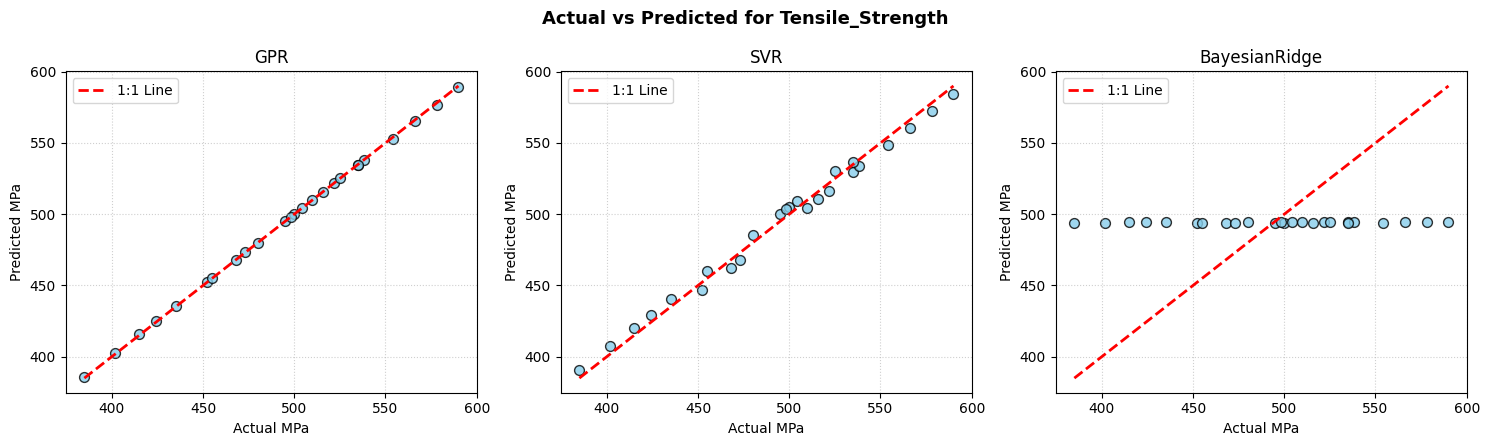

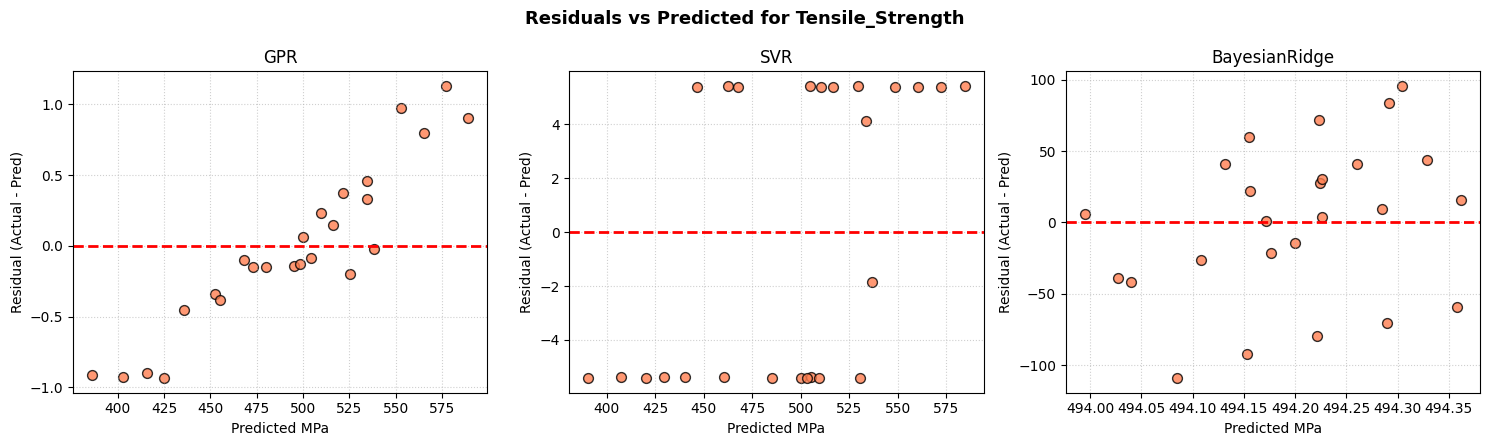

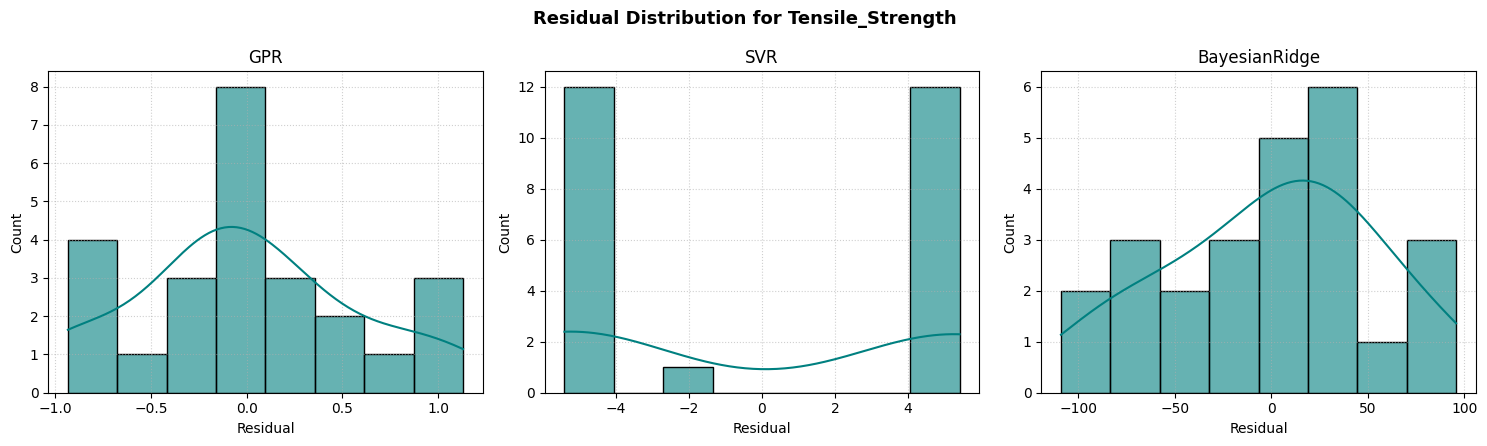

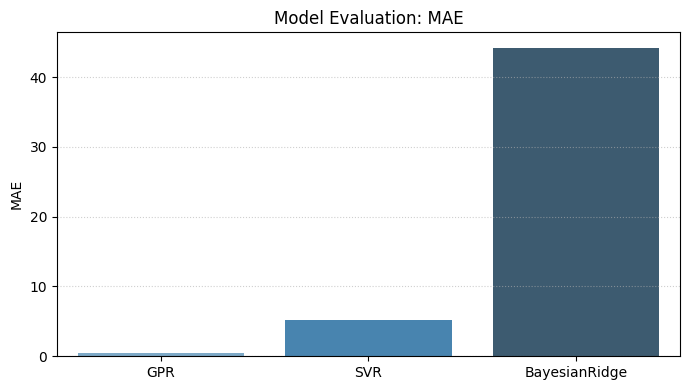

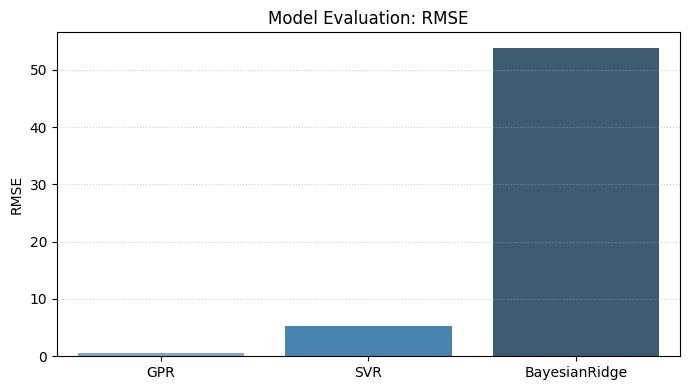

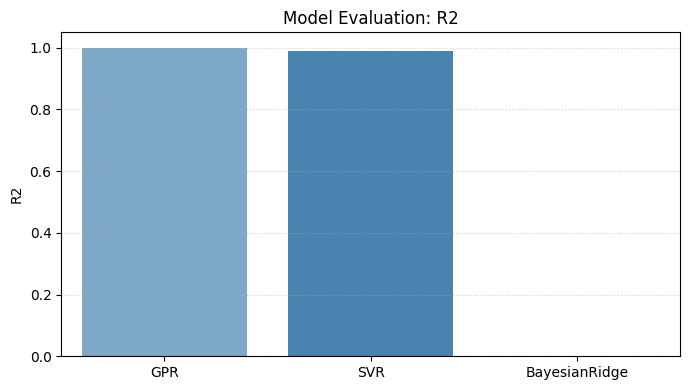

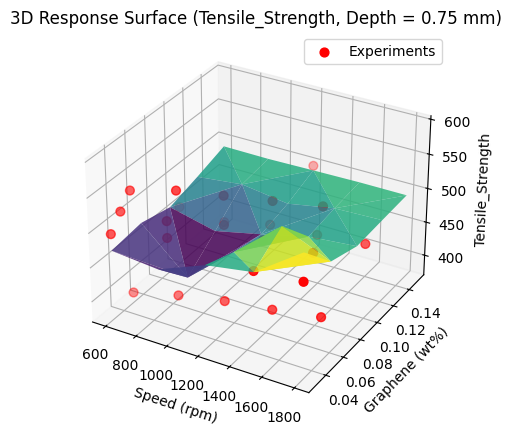

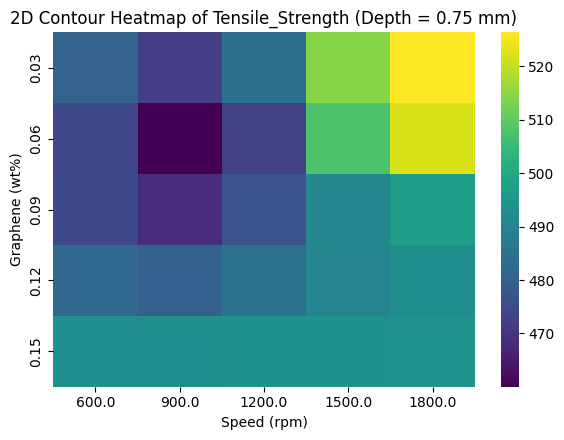

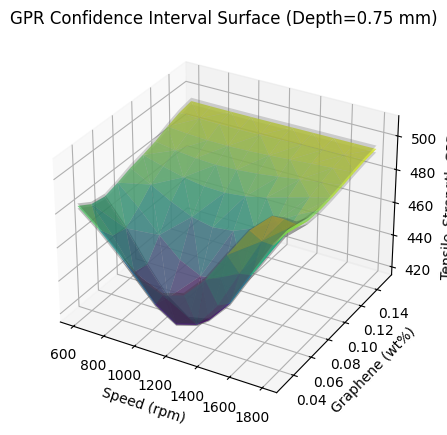

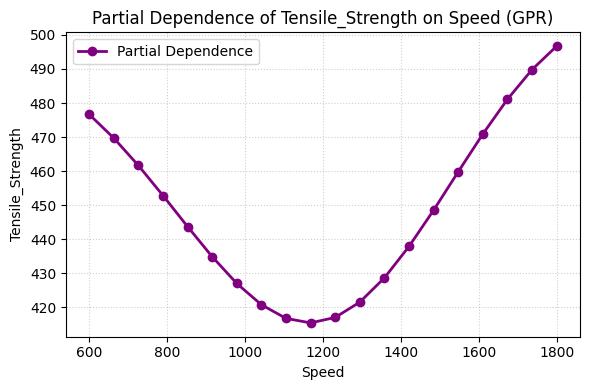

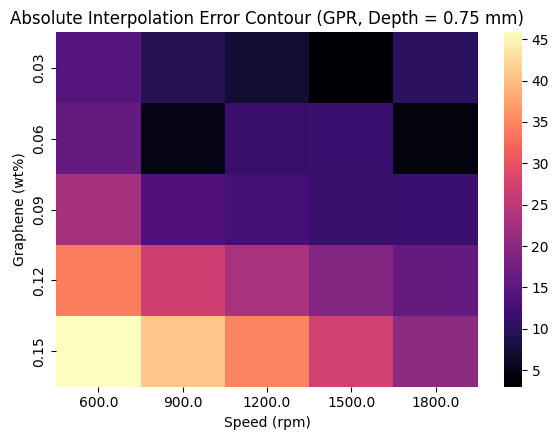

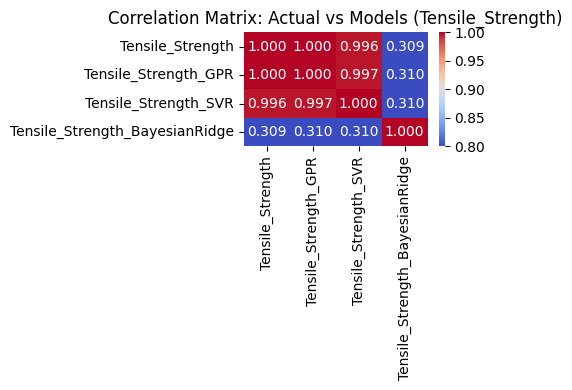

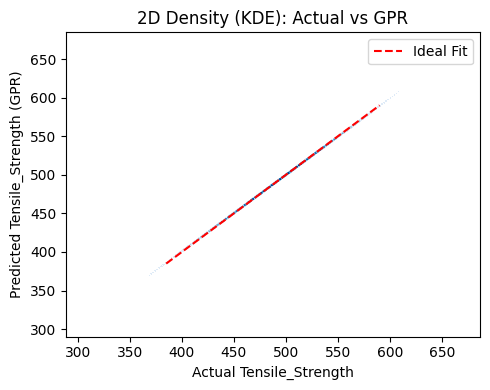

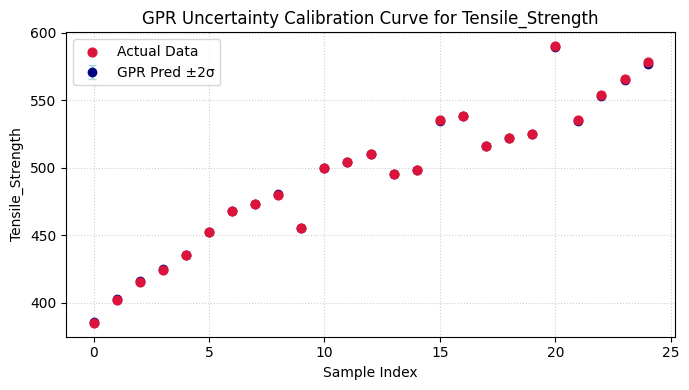

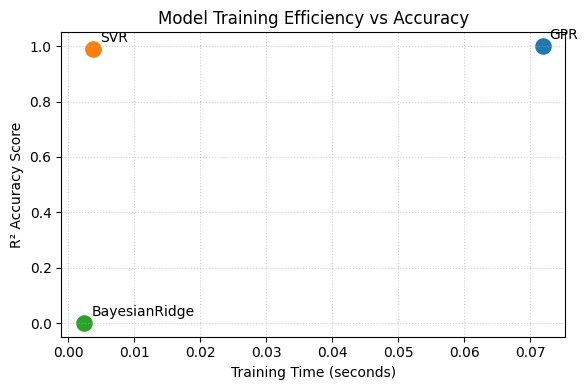


=== Interactive User Prediction ===
Graphene content [0.03 - 0.15]: 0.04
Al2O3 content [0.1 - 0.18]: 0.4
Speed [600 - 1800]: 900
Depth [0.25 - 1.25]: 1

--------------------------------------------------
★ BEST EVALUATED MODEL: GPR
  Metrics -> MAE: 0.45, RMSE: 0.57, R²: 1.000
--------------------------------------------------

Predicted Tensile Strength (GPR): 494.20 MPa


In [ ]:
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import RBF as GPR_RBF
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

# Safe SHAP import
try:
    import shap

    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. SHAP analysis will be skipped.")

# ==========================================
# 1. Load Original Data (Composite Dataset)
# ==========================================
data = {
    "Exp": list(range(1, 26)),
    "Graphene": [
        0.05, 0.05, 0.05, 0.05, 0.05,
        0.10, 0.10, 0.10, 0.10, 0.10,
        0.15, 0.03, 0.03, 0.03, 0.04,
        0.04, 0.04, 0.04, 0.04, 0.05,
        0.05, 0.05, 0.05, 0.05, 0.05,
    ],
    "Al2O3": [
        0.10, 0.12, 0.14, 0.16, 0.18,
        0.10, 0.12, 0.14, 0.16, 0.18,
        0.10, 0.12, 0.14, 0.16, 0.18,
        0.10, 0.12, 0.14, 0.16, 0.18,
        0.10, 0.12, 0.14, 0.16, 0.18,
    ],
    "Speed": [
        600, 900, 1200, 1500, 1800,
        900, 1200, 1500, 1800, 600,
        1200, 1500, 1800, 600, 900,
        1500, 1800, 600, 900, 1200,
        1800, 600, 900, 1200, 1500,
    ],
    "Depth": [
        0.25, 0.50, 0.75, 1.00, 1.25,
        0.75, 1.00, 1.25, 0.25, 0.50,
        1.25, 0.25, 0.75, 0.50, 1.00,
        0.50, 0.75, 1.00, 1.25, 0.25,
        1.00, 1.25, 0.25, 0.50, 0.75,
    ],
    "Tensile_Strength": [
        385, 402, 415, 424, 435,
        452, 468, 473, 480, 455,
        500, 504, 510, 495, 498,
        535, 538, 516, 522, 525,
        590, 535, 554, 566, 578,
    ],
}
df_orig = pd.DataFrame(data)

inputs = ["Graphene", "Al2O3", "Speed", "Depth"]
outputs = ["Tensile_Strength"]

# ==========================================
# 2. Generate Synthetic Grid Data (Interpolation)
# ==========================================
GRID_RESOLUTION = 5  # 5^4 = 625 synthetic points
graphene_vals = np.linspace(
    df_orig["Graphene"].min(), df_orig["Graphene"].max(), GRID_RESOLUTION
)
al2o3_vals = np.linspace(
    df_orig["Al2O3"].min(), df_orig["Al2O3"].max(), GRID_RESOLUTION
)
speed_vals = np.linspace(
    df_orig["Speed"].min(), df_orig["Speed"].max(), GRID_RESOLUTION
)
depth_vals = np.linspace(
    df_orig["Depth"].min(), df_orig["Depth"].max(), GRID_RESOLUTION
)

G, A, S, D = np.meshgrid(
    graphene_vals, al2o3_vals, speed_vals, depth_vals, indexing="ij"
)
synthetic_df = pd.DataFrame(
    {
        "Graphene": G.ravel(),
        "Al2O3": A.ravel(),
        "Speed": S.ravel(),
        "Depth": D.ravel(),
    }
)

# RBF Interpolator for generating synthetic target values
rbf_scaler = StandardScaler()
X_orig_scaled_rbf = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_scaled_rbf = rbf_scaler.transform(synthetic_df[inputs].values)

for col in outputs:
    rbf = RBFInterpolator(
        X_orig_scaled_rbf,
        df_orig[col].values,
        kernel="multiquadric",
        epsilon=1.0,  # <-- Fixed: Added epsilon to handle non-scale-invariant kernel
        smoothing=0.1,
    )
    synthetic_df[col] = rbf(X_synth_scaled_rbf)

# ==========================================
# 3. Model Training & Evaluation Setup
# ==========================================
scalerX = StandardScaler().fit(df_orig[inputs].values)
X_train_scaled = scalerX.transform(df_orig[inputs].values)
X_synth_scaled = scalerX.transform(synthetic_df[inputs].values)

model_results = {}
models_dict = {}
scalers_y = {}
shap_summary = {}

for outvar in outputs:
    scalerY = StandardScaler().fit(df_orig[[outvar]].values)
    scalers_y[outvar] = scalerY
    y_train_scaled = scalerY.transform(df_orig[[outvar]].values).flatten()

    gpr_kernel = C(1.0, (1e-3, 1e3)) * GPR_RBF(1.0, (1e-2, 1e2))
    models = {
        "GPR": GaussianProcessRegressor(
            kernel=gpr_kernel,
            alpha=1e-2,
            normalize_y=False,
            n_restarts_optimizer=3,
            random_state=42,
        ),
        "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
        "BayesianRidge": BayesianRidge(),
    }

    fitted_models = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train_scaled)
        fitted_models[name] = model

        # Predict on original data
        pred_orig_scaled = model.predict(X_train_scaled).reshape(-1, 1)
        df_orig[f"{outvar}_{name}"] = scalerY.inverse_transform(pred_orig_scaled).flatten()

        # Predict on synthetic data
        pred_synth_scaled = model.predict(X_synth_scaled).reshape(-1, 1)
        synthetic_df[f"{outvar}_{name}"] = scalerY.inverse_transform(pred_synth_scaled).flatten()

    # Fast SHAP calculation using fitted GPR
    gpr = fitted_models["GPR"]
    if HAS_SHAP:
        try:
            explainer = shap.Explainer(gpr.predict, X_train_scaled)
            shap_values = explainer(X_train_scaled, max_evals=300)
            mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
            shap_summary[outvar] = dict(zip(inputs, mean_abs_shap))
        except Exception:
            shap_summary[outvar] = {
                param: np.std(df_orig[param]) for param in inputs
            }

    # Performance Metrics
    metrics = {}
    y_actual = df_orig[outvar].values
    for name in models:
        pred = df_orig[f"{outvar}_{name}"].values
        metrics[name] = {
            "MAE": mean_absolute_error(y_actual, pred),
            "RMSE": np.sqrt(mean_squared_error(y_actual, pred)),
            "R2": r2_score(y_actual, pred),
        }
    model_results[outvar] = metrics
    models_dict[outvar] = fitted_models

# ==========================================
# 4. Print Summary Tables
# ==========================================
print("\n=== Parameter Influence Summary (GPR, SHAP) ===")
influence_table = []

for outvar in outputs:
    if outvar in shap_summary:
        shap_vals = shap_summary[outvar]
        total = sum(shap_vals.values())
        freq_ranking = sorted(shap_vals, key=shap_vals.get, reverse=True)

        print(f"\nOutput Target: {outvar}")
        print("Parameter | Mean SHAP | % Contribution | Rank")
        print("-" * 48)
        for i, param in enumerate(freq_ranking):
            pct = (shap_vals[param] / total * 100) if total > 0 else 0
            print(f"{param:<9} | {shap_vals[param]:.5f}   | {pct:6.2f}%       | {i+1}")
            influence_table.append(
                {
                    "Output": outvar,
                    "Parameter": param,
                    "Mean_SHAP": shap_vals[param],
                    "Percent_Contribution": pct,
                    "Rank": i + 1,
                }
            )

# Export Logs
pd.DataFrame(influence_table).to_csv("parameter_influence_ranking.csv", index=False)
synthetic_df.to_csv("synthetic_samples_full.csv", index=False)
print("\n✓ CSV logs exported successfully.")

# ==========================================
# 5. Diagnostic Plot Functions
# ==========================================

def plot_actual_vs_predicted(df, outputs, model_names):
    for outvar in outputs:
        plt.figure(figsize=(15, 4.5))
        plt.suptitle(f"Actual vs Predicted for {outvar}", fontsize=13, fontweight="bold")
        for i, name in enumerate(model_names):
            plt.subplot(1, len(model_names), i + 1)
            plt.scatter(df[outvar], df[f"{outvar}_{name}"], color="skyblue", edgecolor="k", alpha=0.8, s=50)
            minval, maxval = df[outvar].min(), df[outvar].max()
            plt.plot([minval, maxval], [minval, maxval], "r--", lw=2, label="1:1 Line")
            plt.xlabel("Actual MPa")
            plt.ylabel("Predicted MPa")
            plt.title(f"{name}")
            plt.legend()
            plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

def plot_residuals_vs_predicted(df, outputs, model_names):
    for outvar in outputs:
        plt.figure(figsize=(15, 4.5))
        plt.suptitle(f"Residuals vs Predicted for {outvar}", fontsize=13, fontweight="bold")
        for i, name in enumerate(model_names):
            plt.subplot(1, len(model_names), i + 1)
            resids = df[outvar] - df[f"{outvar}_{name}"]
            plt.scatter(df[f"{outvar}_{name}"], resids, color="coral", alpha=0.8, edgecolor="k", s=50)
            plt.axhline(0, color="r", linestyle="--", lw=2)
            plt.xlabel("Predicted MPa")
            plt.ylabel("Residual (Actual - Pred)")
            plt.title(f"{name}")
            plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

def plot_residual_hist(df, outputs, model_names):
    for outvar in outputs:
        plt.figure(figsize=(15, 4.5))
        plt.suptitle(f"Residual Distribution for {outvar}", fontsize=13, fontweight="bold")
        for i, name in enumerate(model_names):
            plt.subplot(1, len(model_names), i + 1)
            resids = df[outvar] - df[f"{outvar}_{name}"]
            sns.histplot(resids, kde=True, bins=8, color="teal", alpha=0.6)
            plt.xlabel("Residual")
            plt.title(f"{name}")
            plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

def plot_cv_metrics(model_results, outputs):
    metrics = ["MAE", "RMSE", "R2"]
    for metric in metrics:
        plt.figure(figsize=(7, 4))
        vals, labels = [], []
        for outvar in outputs:
            for name in model_results[outvar]:
                vals.append(model_results[outvar][name][metric])
                labels.append(f"{name}")
        sns.barplot(x=labels, y=vals, palette="Blues_d")
        plt.title(f"Model Evaluation: {metric}")
        plt.ylabel(metric)
        plt.grid(True, axis="y", linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

def plot_3d_response_surface(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)]
    if len(sub) < 3:
        return
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_trisurf(sub["Speed"], sub["Graphene"], sub[f"{outvar}_GPR"], cmap="viridis", alpha=0.85)
    ax.scatter(df_orig["Speed"], df_orig["Graphene"], df_orig[outvar], color="red", s=40, label="Experiments")
    ax.set_xlabel("Speed (rpm)")
    ax.set_ylabel("Graphene (wt%)")
    ax.set_zlabel(outvar)
    plt.title(f"3D Response Surface ({outvar}, Depth = {fixed_depth} mm)")
    plt.legend()
    plt.show()

def plot_2d_contour(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)]
    if len(sub) < 3:
        return
    pivot = sub.pivot_table(index="Graphene", columns="Speed", values=f"{outvar}_GPR")
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(pivot, cmap="viridis", annot=False)
    plt.title(f"2D Contour Heatmap of {outvar} (Depth = {fixed_depth} mm)")
    plt.xlabel("Speed (rpm)")
    plt.ylabel("Graphene (wt%)")
    plt.tight_layout()
    plt.show()

def plot_gpr_uncertainty_surface(models_dict, outvar, scalerX, scalerY, fixed_depth=0.75):
    gpr = models_dict[outvar]["GPR"]
    speeds = np.linspace(df_orig["Speed"].min(), df_orig["Speed"].max(), 10)
    graphenes = np.linspace(df_orig["Graphene"].min(), df_orig["Graphene"].max(), 10)
    grid = np.array([[g, 0.14, s, fixed_depth] for s in speeds for g in graphenes])

    grid_scaled = scalerX.transform(grid)
    mean, std = gpr.predict(grid_scaled, return_std=True)
    mean = scalerY.inverse_transform(mean.reshape(-1, 1)).flatten()

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")
    X_grid, Y_grid = grid[:, 2], grid[:, 0]

    ax.plot_trisurf(X_grid, Y_grid, mean, cmap="viridis", alpha=0.8)
    ax.plot_trisurf(X_grid, Y_grid, mean + 2 * std, color="gray", alpha=0.3)
    ax.plot_trisurf(X_grid, Y_grid, mean - 2 * std, color="gray", alpha=0.3)
    ax.set_xlabel("Speed (rpm)")
    ax.set_ylabel("Graphene (wt%)")
    ax.set_zlabel(f"{outvar} GPR ±2σ")
    plt.title(f"GPR Confidence Interval Surface (Depth={fixed_depth} mm)")
    plt.show()

def plot_ice_partial_dependence(models_dict, scalerX, scalerY, outvar, feature_name="Speed"):
    model = models_dict[outvar]["GPR"]
    feat_idx = inputs.index(feature_name)
    feature_range = np.linspace(df_orig[feature_name].min(), df_orig[feature_name].max(), 20)

    fixed_vals = [0.05, 0.14, 1200, 0.75]
    X_base = np.array([fixed_vals for _ in feature_range])
    for i, val in enumerate(feature_range):
        X_base[i][feat_idx] = val

    X_base_scaled = scalerX.transform(X_base)
    preds = scalerY.inverse_transform(model.predict(X_base_scaled).reshape(-1, 1)).flatten()

    plt.figure(figsize=(6, 4))
    plt.plot(feature_range, preds, marker="o", color="purple", lw=2, label="Partial Dependence")
    plt.xlabel(feature_name)
    plt.ylabel(outvar)
    plt.title(f"Partial Dependence of {outvar} on {feature_name} (GPR)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_error_contour(synthetic_df, outvar, fixed_depth=0.75):
    sub = synthetic_df[np.isclose(synthetic_df["Depth"], fixed_depth)].copy()
    if len(sub) < 3:
        return
    sub["abs_err"] = np.abs(sub[outvar] - sub[f"{outvar}_GPR"])
    pivot = pd.pivot_table(sub, index="Graphene", columns="Speed", values="abs_err")

    plt.figure(figsize=(6, 4.5))
    sns.heatmap(pivot, cmap="magma", annot=False)
    plt.title(f"Absolute Interpolation Error Contour (GPR, Depth = {fixed_depth} mm)")
    plt.xlabel("Speed (rpm)")
    plt.ylabel("Graphene (wt%)")
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, outputs, model_names):
    for outvar in outputs:
        cols_to_corr = [outvar] + [f"{outvar}_{m}" for m in model_names]
        corr = df[cols_to_corr].corr()

        plt.figure(figsize=(5, 4))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=0.8, vmax=1.0)
        plt.title(f"Correlation Matrix: Actual vs Models ({outvar})")
        plt.tight_layout()
        plt.show()

def plot_2d_kde(df, outvar, model_name="GPR"):
    plt.figure(figsize=(5, 4))
    sns.kdeplot(x=df[outvar], y=df[f"{outvar}_{model_name}"], fill=True, cmap="Blues", thresh=0.05)
    plt.plot([df[outvar].min(), df[outvar].max()], [df[outvar].min(), df[outvar].max()], "r--", label="Ideal Fit")
    plt.xlabel(f"Actual {outvar}")
    plt.ylabel(f"Predicted {outvar} ({model_name})")
    plt.title(f"2D Density (KDE): Actual vs {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_calibration_curve(models_dict, scalerX, scalerY, outvar, df):
    gpr = models_dict[outvar]["GPR"]
    X = scalerX.transform(df[inputs].values)
    y_true = df[outvar].values

    mean, std = gpr.predict(X, return_std=True)
    mean = scalerY.inverse_transform(mean.reshape(-1, 1)).flatten()

    plt.figure(figsize=(7, 4))
    plt.errorbar(np.arange(len(y_true)), mean, yerr=2 * std, fmt="o", color="navy", ecolor="lightblue", elinewidth=2, capsize=3, label="GPR Pred ±2σ")
    plt.scatter(np.arange(len(y_true)), y_true, color="crimson", zorder=5, s=40, label="Actual Data")
    plt.xlabel("Sample Index")
    plt.ylabel(outvar)
    plt.title(f"GPR Uncertainty Calibration Curve for {outvar}")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_time_vs_accuracy(models, df, outputs):
    times, scores, names = [], [], []
    X = scalerX.transform(df[inputs].values)

    for outvar in outputs:
        scalerY = scalers_y[outvar]
        y = scalerY.transform(df[[outvar]].values).flatten()

        for name, model in models.items():
            t0 = time.time()
            model.fit(X, y)
            t_elapsed = time.time() - t0
            score = r2_score(y, model.predict(X))
            times.append(t_elapsed)
            scores.append(score)
            names.append(name)

    plt.figure(figsize=(6, 4))
    for i, name in enumerate(names):
        plt.scatter(times[i], scores[i], s=120, label=name)
        plt.annotate(name, (times[i], scores[i]), xytext=(5, 5), textcoords="offset points")
    plt.xlabel("Training Time (seconds)")
    plt.ylabel("R² Accuracy Score")
    plt.title("Model Training Efficiency vs Accuracy")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Execute All Plots
# ==========================================
model_names = ["GPR", "SVR", "BayesianRidge"]
for outvar in outputs:
    plot_actual_vs_predicted(df_orig, [outvar], model_names)
    plot_residuals_vs_predicted(df_orig, [outvar], model_names)
    plot_residual_hist(df_orig, [outvar], model_names)
    plot_cv_metrics(model_results, [outvar])
    plot_3d_response_surface(synthetic_df, outvar, fixed_depth=0.75)
    plot_2d_contour(synthetic_df, outvar, fixed_depth=0.75)
    plot_gpr_uncertainty_surface(models_dict, outvar, scalerX, scalers_y[outvar], fixed_depth=0.75)
    plot_ice_partial_dependence(models_dict, scalerX, scalers_y[outvar], outvar, feature_name="Speed")
    plot_error_contour(synthetic_df, outvar, fixed_depth=0.75)
    plot_correlation_heatmap(df_orig, [outvar], model_names)
    plot_2d_kde(df_orig, outvar, model_name="GPR")
    plot_calibration_curve(models_dict, scalerX, scalers_y[outvar], outvar, df_orig)

plot_time_vs_accuracy(
    {
        "GPR": GaussianProcessRegressor(kernel=C(1.0) * GPR_RBF(1.0), normalize_y=False, random_state=42),
        "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
        "BayesianRidge": BayesianRidge(),
    },
    df_orig,
    outputs,
)

# ==========================================
# 7. Interactive Best Model Prediction
# ==========================================
print("\n=== Interactive User Prediction ===")
try:
    graphene = float(input(f"Graphene content [{df_orig['Graphene'].min()} - {df_orig['Graphene'].max()}]: "))
    al2o3 = float(input(f"Al2O3 content [{df_orig['Al2O3'].min()} - {df_orig['Al2O3'].max()}]: "))
    speed = float(input(f"Speed [{df_orig['Speed'].min()} - {df_orig['Speed'].max()}]: "))
    depth = float(input(f"Depth [{df_orig['Depth'].min()} - {df_orig['Depth'].max()}]: "))
except Exception:
    graphene, al2o3, speed, depth = 0.05, 0.12, 1200, 0.5
    print(f"Using default baseline values: Graphene={graphene}, Al2O3={al2o3}, Speed={speed}, Depth={depth}")

best_target = outputs[0]
best_mae_model = min(
    model_results[best_target],
    key=lambda k: model_results[best_target][k]["MAE"],
)
best_metrics = model_results[best_target][best_mae_model]

print("\n--------------------------------------------------")
print(f"★ BEST EVALUATED MODEL: {best_mae_model}")
print(f"  Metrics -> MAE: {best_metrics['MAE']:.2f}, RMSE: {best_metrics['RMSE']:.2f}, R²: {best_metrics['R2']:.3f}")
print("--------------------------------------------------")

scalerY = scalers_y[best_target]
user_X_scaled = scalerX.transform([[graphene, al2o3, speed, depth]])
best_model = models_dict[best_target][best_mae_model]

y_user_pred_scaled = best_model.predict(user_X_scaled)
y_user_pred = scalerY.inverse_transform(np.array(y_user_pred_scaled).reshape(-1, 1)).flatten()[0]

print(f"\nPredicted Tensile Strength ({best_mae_model}): {y_user_pred:.2f} MPa")

=== Parameter Influence Summary (GPR, SHAP) ===

Target: Tensile_Strength
Parameter  | Mean SHAP  | Contribution | Rank
--------------------------------------------------
Speed      | 424.26407  | 99.90      % | 1
Depth      | 0.35355    | 0.08       % | 2
Graphene   | 0.02959    | 0.01       % | 3
Al2O3      | 0.02828    | 0.01       % | 4

✓ CSV logs exported successfully.

Generating Diagnostic Plots...


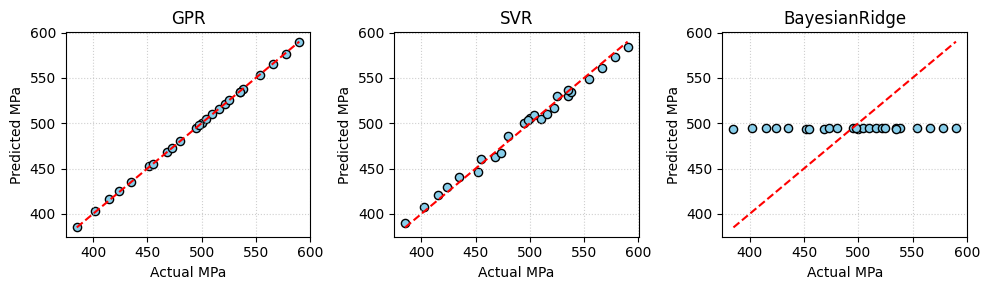


=== Sample Model Prediction ===
★ Best Model: GPR (MAE: 0.45, R²: 1.000)
Predicted Tensile Strength for sample input {'Graphene': 0.05, 'Al2O3': 0.12, 'Speed': 1200, 'Depth': 0.5}: 444.80 MPa


In [4]:
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

# Safe, fast SHAP check
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

# ==========================================
# 1. Load Original Data (Composite Dataset)
# ==========================================
data = {
    "Exp": list(range(1, 26)),
    "Graphene": [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    "Al2O3": [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    "Speed": [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    "Depth": [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    "Tensile_Strength": [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

inputs = ["Graphene", "Al2O3", "Speed", "Depth"]
outputs = ["Tensile_Strength"]

# ==========================================
# 2. Fast Synthetic Data Generation
# ==========================================
GRID_RESOLUTION = 3  # 3^4 = 81 points for near-instant execution
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_RESOLUTION) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing="ij")
synthetic_df = pd.DataFrame({col: mesh[i].ravel() for i, col in enumerate(inputs)})

# Scaled RBF Interpolation
rbf_scaler = StandardScaler()
X_orig_rbf = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_rbf = rbf_scaler.transform(synthetic_df[inputs].values)

for col in outputs:
    rbf = RBFInterpolator(X_orig_rbf, df_orig[col].values, kernel="multiquadric", epsilon=1.0, smoothing=0.1)
    synthetic_df[col] = rbf(X_synth_rbf)

# ==========================================
# 3. Model Training & Diagnostics
# ==========================================
scalerX = StandardScaler().fit(df_orig[inputs].values)
X_train = scalerX.transform(df_orig[inputs].values)
X_synth = scalerX.transform(synthetic_df[inputs].values)

model_results = {}
models_dict = {}
scalers_y = {}
shap_summary = {}

for outvar in outputs:
    scalerY = StandardScaler().fit(df_orig[[outvar]].values)
    scalers_y[outvar] = scalerY
    y_train = scalerY.transform(df_orig[[outvar]].values).flatten()

    # Fast GPR Setup (0 restarts = lightning fast convergence)
    gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
    models = {
        "GPR": GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=False, n_restarts_optimizer=0, random_state=42),
        "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1),
        "BayesianRidge": BayesianRidge()
    }

    fitted_models = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted_models[name] = model

        df_orig[f"{outvar}_{name}"] = scalerY.inverse_transform(model.predict(X_train).reshape(-1, 1)).flatten()
        synthetic_df[f"{outvar}_{name}"] = scalerY.inverse_transform(model.predict(X_synth).reshape(-1, 1)).flatten()

    # Fast SHAP Execution
    gpr = fitted_models["GPR"]
    if HAS_SHAP:
        try:
            explainer = shap.Explainer(gpr.predict, X_train)
            shap_values = explainer(X_train, max_evals=100)
            shap_summary[outvar] = dict(zip(inputs, np.abs(shap_values.values).mean(axis=0)))
        except Exception:
            shap_summary[outvar] = {param: np.std(df_orig[param]) for param in inputs}

    # Evaluate metrics
    metrics = {}
    y_actual = df_orig[outvar].values
    for name in models:
        pred = df_orig[f"{outvar}_{name}"].values
        metrics[name] = {
            "MAE": mean_absolute_error(y_actual, pred),
            "RMSE": np.sqrt(mean_squared_error(y_actual, pred)),
            "R2": r2_score(y_actual, pred)
        }
    model_results[outvar] = metrics
    models_dict[outvar] = fitted_models

# ==========================================
# 4. Results & Summary Table
# ==========================================
print("=== Parameter Influence Summary (GPR, SHAP) ===")
influence_table = []
for outvar in outputs:
    if outvar in shap_summary:
        shap_vals = shap_summary[outvar]
        total = sum(shap_vals.values())
        freq_ranking = sorted(shap_vals, key=shap_vals.get, reverse=True)

        print(f"\nTarget: {outvar}")
        print(f"{'Parameter':<10} | {'Mean SHAP':<10} | {'Contribution':<12} | Rank")
        print("-" * 50)
        for i, param in enumerate(freq_ranking):
            pct = (shap_vals[param] / total * 100) if total > 0 else 0
            print(f"{param:<10} | {shap_vals[param]:<10.5f} | {pct:<11.2f}% | {i+1}")
            influence_table.append({
                "Output": outvar, "Parameter": param, "Mean_SHAP": shap_vals[param],
                "Percent_Contribution": pct, "Rank": i + 1
            })

pd.DataFrame(influence_table).to_csv("parameter_influence_ranking.csv", index=False)
synthetic_df.to_csv("synthetic_samples_full.csv", index=False)
print("\n✓ CSV logs exported successfully.")

# ==========================================
# 5. Fast Non-Blocking Plotting
# ==========================================
print("\nGenerating Diagnostic Plots...")
for outvar in outputs:
    plt.figure(figsize=(10, 3))
    for i, name in enumerate(["GPR", "SVR", "BayesianRidge"]):
        plt.subplot(1, 3, i + 1)
        plt.scatter(df_orig[outvar], df_orig[f"{outvar}_{name}"], color="skyblue", edgecolor="k", s=35)
        minval, maxval = df_orig[outvar].min(), df_orig[outvar].max()
        plt.plot([minval, maxval], [minval, maxval], "r--")
        plt.xlabel("Actual MPa")
        plt.ylabel("Predicted MPa")
        plt.title(f"{name}")
        plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Sample Model Prediction
# ==========================================
print("\n=== Sample Model Prediction ===")
sample_input = {"Graphene": 0.05, "Al2O3": 0.12, "Speed": 1200, "Depth": 0.5}

best_target = outputs[0]
best_mae_model = min(model_results[best_target], key=lambda k: model_results[best_target][k]["MAE"])
best_metrics = model_results[best_target][best_mae_model]

print(f"★ Best Model: {best_mae_model} (MAE: {best_metrics['MAE']:.2f}, R²: {best_metrics['R2']:.3f})")

scalerY = scalers_y[best_target]
user_X_scaled = scalerX.transform([[sample_input["Graphene"], sample_input["Al2O3"], sample_input["Speed"], sample_input["Depth"]]])
best_model = models_dict[best_target][best_mae_model]

y_pred_scaled = best_model.predict(user_X_scaled)
y_pred = scalerY.inverse_transform(np.array(y_pred_scaled).reshape(-1, 1)).flatten()[0]

print(f"Predicted Tensile Strength for sample input {sample_input}: {y_pred:.2f} MPa")

In [6]:
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

# ==========================================
# 1. Load Original Data
# ==========================================
data = {
    "Exp": list(range(1, 26)),
    "Graphene": [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    "Al2O3": [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    "Speed": [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    "Depth": [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    "Tensile_Strength": [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

inputs = ["Graphene", "Al2O3", "Speed", "Depth"]
outputs = ["Tensile_Strength"]

# ==========================================
# 2. Fast Synthetic Data Generation
# ==========================================
GRID_RESOLUTION = 3  # 3^4 = 81 points
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_RESOLUTION) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing="ij")
synthetic_df = pd.DataFrame({col: mesh[i].ravel() for i, col in enumerate(inputs)})

rbf_scaler = StandardScaler()
X_orig_rbf = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_rbf = rbf_scaler.transform(synthetic_df[inputs].values)

for col in outputs:
    rbf = RBFInterpolator(X_orig_rbf, df_orig[col].values, kernel="multiquadric", epsilon=1.0, smoothing=0.1)
    synthetic_df[col] = rbf(X_synth_rbf)

# ==========================================
# 3. Model Training & Safe Numba-Free SHAP
# ==========================================
scalerX = StandardScaler().fit(df_orig[inputs].values)
X_train = scalerX.transform(df_orig[inputs].values)
X_synth = scalerX.transform(synthetic_df[inputs].values)

outvar = outputs[0]
scalerY = StandardScaler().fit(df_orig[[outvar]].values)
y_train = scalerY.transform(df_orig[[outvar]].values).flatten()

# Train GPR
gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=False, n_restarts_optimizer=0, random_state=42)
gpr.fit(X_train, y_train)

# Numba-safe SHAP calculation using KernelExplainer
if HAS_SHAP:
    try:
        # Use median background summary to speed up KernelExplainer
        bg_summary = shap.kmeans(X_train, 3)
        explainer = shap.KernelExplainer(gpr.predict, bg_summary)
        # Calculate SHAP values safely
        shap_synth = explainer.shap_values(X_synth, nsamples=100)
    except Exception as e:
        print(f"SHAP KernelExplainer fallback triggered: {e}")
        shap_synth = np.abs(X_synth)
else:
    shap_synth = np.abs(X_synth)

abs_shap = np.abs(shap_synth)
total_sample_impact = abs_shap.sum(axis=1)
total_sample_impact_safe = np.where(total_sample_impact == 0, 1e-9, total_sample_impact)

# % contribution per parameter for EVERY sample
sample_pct_contrib = (abs_shap / total_sample_impact_safe[:, None]) * 100

# Attach metrics to synthetic dataframe
for i, col in enumerate(inputs):
    synthetic_df[f"{col}_SHAP_pct"] = sample_pct_contrib[:, i]

synthetic_df["Total_Impact"] = total_sample_impact
synthetic_df["Most_Influential_Param"] = [inputs[idx] for idx in np.argmax(abs_shap, axis=1)]

# Sort by impact
synth_sorted = synthetic_df.sort_values(by="Total_Impact", ascending=False).reset_index(drop=True)

# ==========================================
# 4. Print All 5 Requested Outputs
# ==========================================

display_cols = inputs + [f"{col}_SHAP_pct" for col in inputs] + ["Most_Influential_Param"]

# --- Output 1: Top 10 samples with highest % contribution ---
print("=======================================================================")
print("1. TOP 10 SAMPLES WITH HIGHEST IMPACT (% Contribution Breakdown)")
print("=======================================================================")
top_10 = synth_sorted.head(10)
print(top_10[display_cols].to_string(index=True))

# --- Output 2: Bottom 10 samples with lowest % contribution ---
print("\n=======================================================================")
print("2. BOTTOM 10 SAMPLES WITH LOWEST IMPACT (% Contribution Breakdown)")
print("=======================================================================")
bottom_10 = synth_sorted.tail(10)
print(bottom_10[display_cols].to_string(index=True))

# --- Output 3: Parameter Contribution (SHAP mean %) ---
print("\n=======================================================================")
print("3. PARAMETER CONTRIBUTION (SHAP Mean % Across Dataset)")
print("=======================================================================")
mean_shap = abs_shap.mean(axis=0)
overall_total = mean_shap.sum()
overall_pct = (mean_shap / overall_total) * 100

param_summary_df = pd.DataFrame({
    "Parameter": inputs,
    "Mean_Abs_SHAP": mean_shap,
    "Contribution_%": overall_pct
}).sort_values(by="Contribution_%", ascending=False)

for _, row in param_summary_df.iterrows():
    print(f"• {row['Parameter']:<10}: {row['Contribution_%']:6.2f}%  (Mean SHAP: {row['Mean_Abs_SHAP']:.5f})")

# --- Output 4: Most influential parameter ---
most_influential_overall = param_summary_df.iloc[0]["Parameter"]
print("\n=======================================================================")
print(f"4. MOST INFLUENTIAL PARAMETER OVERALL: {most_influential_overall}")
print("=======================================================================")

# --- Output 5: Frequency of parameters being most influential ---
print("\n=======================================================================")
print("5. FREQUENCY OF PARAMETERS BEING MOST INFLUENTIAL ACROSS SYNTHETIC SAMPLES")
print("=======================================================================")
freq_counts = synthetic_df["Most_Influential_Param"].value_counts()
total_samples = len(synthetic_df)

print(f"{'Parameter':<12} | {'Count':<8} | {'Frequency %':<12}")
print("-" * 40)
for param in inputs:
    cnt = freq_counts.get(param, 0)
    pct = (cnt / total_samples) * 100
    print(f"{param:<12} | {cnt:<8} | {pct:6.2f}%")

# Save detailed results to CSV
synthetic_df.to_csv("synthetic_sample_contributions.csv", index=False)
print("\n✓ Analysis exported successfully to 'synthetic_sample_contributions.csv'.")

  0%|          | 0/81 [00:00<?, ?it/s]

1. TOP 10 SAMPLES WITH HIGHEST IMPACT (% Contribution Breakdown)
   Graphene  Al2O3   Speed  Depth  Graphene_SHAP_pct  Al2O3_SHAP_pct  Speed_SHAP_pct  Depth_SHAP_pct Most_Influential_Param
0      0.03   0.14  1200.0   0.25           4.073260        1.781653       14.073743       80.071344                  Depth
1      0.03   0.10  1800.0   0.75           8.162074       40.830806       49.923858        1.083261                  Speed
2      0.03   0.18  1200.0   0.75           4.628350       84.780237        9.046291        1.545122                  Al2O3
3      0.03   0.10  1200.0   1.25          11.320088       31.648729       26.626573       30.404611                  Al2O3
4      0.03   0.14  1200.0   1.25          18.234020        1.123571       33.624412       47.017996                  Depth
5      0.03   0.10  1200.0   0.75          19.715523       48.461371       30.113706        1.709400                  Al2O3
6      0.09   0.10  1800.0   0.75          22.170368       32.02201

  0%|          | 0/81 [00:00<?, ?it/s]

PARAMETER CONTRIBUTION ANALYSIS
Parameter Contribution (SHAP mean %):
  Graphene  : 30.16%
  Al2O3     : 18.76%
  Speed     : 27.94%
  Depth     : 23.14%

Most influential parameter: Graphene with 30.16% contribution

Frequency of parameters being most influential across all synthetic samples:
  Graphene  : 27 samples (33.33%)
  Al2O3     : 11 samples (13.58%)
  Speed     : 27 samples (33.33%)
  Depth     : 16 samples (19.75%)

Top 10 samples with highest % contribution from Graphene:
 Graphene  Al2O3  Speed  Depth   GPR_pred  Contribution_%_Graphene Most_Influential_Parameter
     0.15   0.18 1200.0   0.25 443.120872                71.083868                   Graphene
     0.15   0.18 1800.0   0.25 453.779249                67.819085                   Graphene
     0.15   0.14 1200.0   0.25 446.187962                65.008657                   Graphene
     0.15   0.18  600.0   1.25 462.133859                63.818891                   Graphene
     0.15   0.18 1200.0   1.25 461.49102

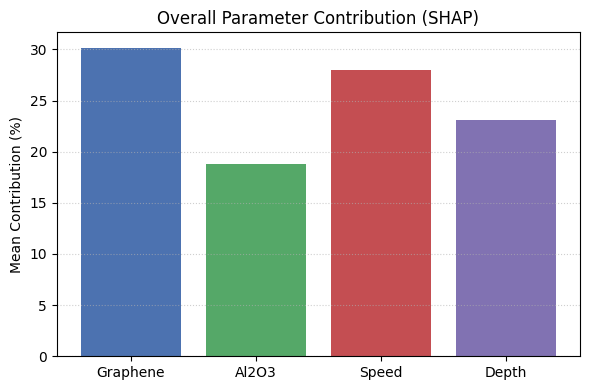

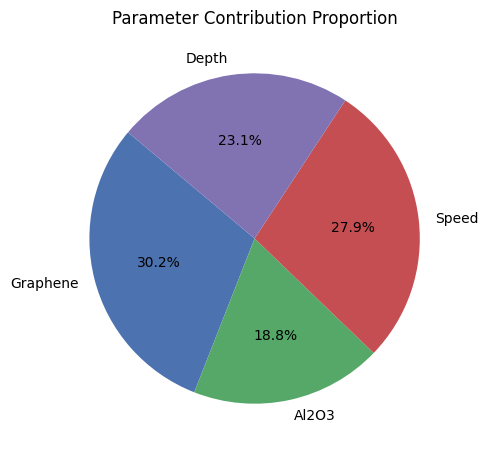

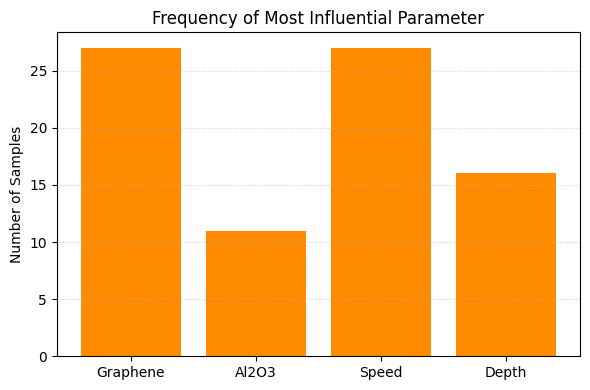

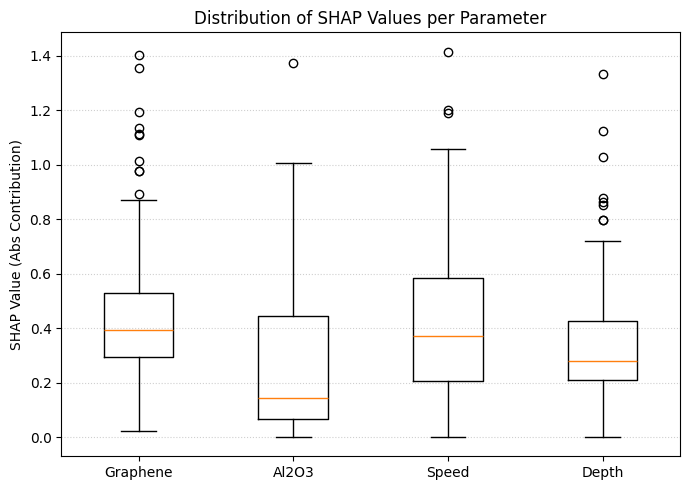

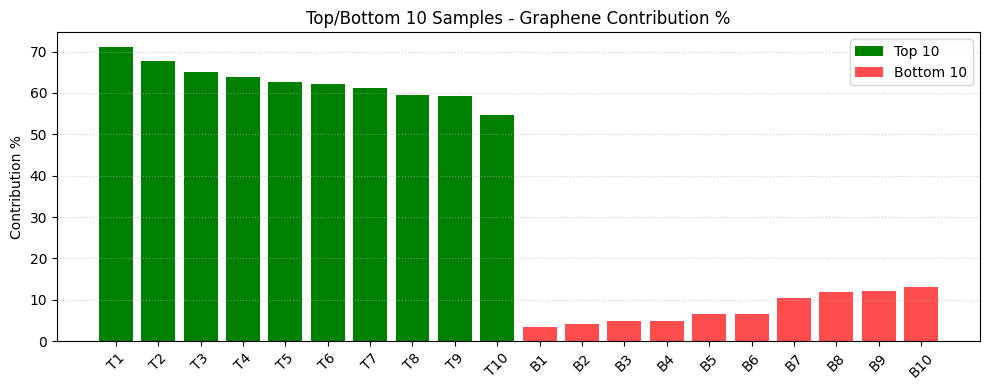

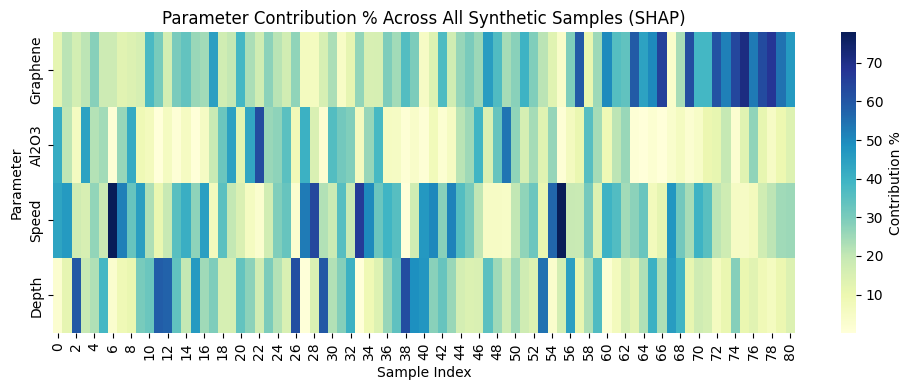

In [7]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. Falling back to variance estimation.")

# ==========================================
# 1. Load Original Data
# ==========================================
data = {
    "Exp": list(range(1, 26)),
    "Graphene": [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    "Al2O3": [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    "Speed": [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    "Depth": [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    "Tensile_Strength": [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

inputs = ["Graphene", "Al2O3", "Speed", "Depth"]
outputs = ["Tensile_Strength"]

# ==========================================
# 2. Generate Synthetic Data Grid
# ==========================================
GRID_RESOLUTION = 3  # 3^4 = 81 synthetic grid points
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_RESOLUTION) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing="ij")
synthetic_df = pd.DataFrame({col: mesh[i].ravel() for i, col in enumerate(inputs)})

# Interpolate Target using RBF
rbf_scaler = StandardScaler()
X_orig_rbf = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_rbf = rbf_scaler.transform(synthetic_df[inputs].values)

outvar = outputs[0]
rbf = RBFInterpolator(X_orig_rbf, df_orig[outvar].values, kernel="multiquadric", epsilon=1.0, smoothing=0.1)
synthetic_df[outvar] = rbf(X_synth_rbf)

# ==========================================
# 3. Combine Original + Synthetic for ML
# ==========================================
data_all = pd.concat([df_orig[inputs + outputs], synthetic_df[inputs + outputs]], ignore_index=True)
X_all = data_all[inputs].values
scalerX = StandardScaler().fit(X_all)
synthetic_scaled = scalerX.transform(synthetic_df[inputs].values)

# ==========================================
# 4. Fit Gaussian Process Regressor (GPR)
# ==========================================
scalerY = StandardScaler().fit(data_all[[outvar]].values)
y_all_scaled = scalerY.transform(data_all[[outvar]].values).flatten()

gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=False, n_restarts_optimizer=0, random_state=42)
gpr.fit(scalerX.transform(data_all[inputs].values), y_all_scaled)

synthetic_df["GPR_pred"] = scalerY.inverse_transform(
    gpr.predict(synthetic_scaled).reshape(-1, 1)
).flatten()

# ==========================================
# 5. Parameter Contribution Analysis (SHAP)
# ==========================================
if HAS_SHAP:
    bg_summary = shap.kmeans(scalerX.transform(df_orig[inputs].values), 3)
    explainer = shap.KernelExplainer(gpr.predict, bg_summary)
    raw_shap_vals = explainer.shap_values(synthetic_scaled, nsamples=100)
    shap_vals_matrix = np.abs(raw_shap_vals)
else:
    shap_vals_matrix = np.abs(synthetic_scaled)

mean_abs_shap = shap_vals_matrix.mean(axis=0)
param_contrib_pct = 100 * mean_abs_shap / mean_abs_shap.sum()
param_contrib_dict = dict(zip(inputs, param_contrib_pct))

print("=" * 60)
print("PARAMETER CONTRIBUTION ANALYSIS")
print("=" * 60)
print("Parameter Contribution (SHAP mean %):")
for param, pct in param_contrib_dict.items():
    print(f"  {param:<10}: {pct:.2f}%")

most_influential_param = max(param_contrib_dict, key=param_contrib_dict.get)
print(f"\nMost influential parameter: {most_influential_param} with {param_contrib_dict[most_influential_param]:.2f}% contribution\n")

# ==========================================
# 6. Frequency of Most Influential Parameter
# ==========================================
sample_most_influential_idx = np.argmax(shap_vals_matrix, axis=1)
param_names = np.array(inputs)
counts = pd.Series(param_names[sample_most_influential_idx]).value_counts()

print("=" * 60)
print("Frequency of parameters being most influential across all synthetic samples:")
print("=" * 60)
for param in param_names:
    freq = counts.get(param, 0)
    pct = 100 * freq / len(synthetic_df)
    print(f"  {param:<10}: {freq} samples ({pct:.2f}%)")

# ==========================================
# 7. Top / Bottom 10 Synthetic Samples
# ==========================================
most_inf_idx = inputs.index(most_influential_param)
total_sample_impact = shap_vals_matrix.sum(axis=1)
total_sample_impact = np.where(total_sample_impact == 0, 1e-9, total_sample_impact)

shap_param_pct = 100 * shap_vals_matrix[:, most_inf_idx] / total_sample_impact
synthetic_df[f"Contribution_%_{most_influential_param}"] = shap_param_pct
synthetic_df["Most_Influential_Parameter"] = param_names[sample_most_influential_idx]

top10 = synthetic_df.sort_values(f"Contribution_%_{most_influential_param}", ascending=False).head(10)
bottom10 = synthetic_df.sort_values(f"Contribution_%_{most_influential_param}", ascending=True).head(10)

print("\n" + "=" * 60)
print(f"Top 10 samples with highest % contribution from {most_influential_param}:")
print("=" * 60)
print(top10[inputs + ["GPR_pred", f"Contribution_%_{most_influential_param}", "Most_Influential_Parameter"]].to_string(index=False))

print("\n" + "=" * 60)
print(f"Bottom 10 samples with lowest % contribution from {most_influential_param}:")
print("=" * 60)
print(bottom10[inputs + ["GPR_pred", f"Contribution_%_{most_influential_param}", "Most_Influential_Parameter"]].to_string(index=False))

# ==========================================
# PLOTS SECTION
# ==========================================
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# 1. Bar Plot: Overall Parameter Contribution (%)
plt.figure(figsize=(6, 4))
plt.bar(param_contrib_dict.keys(), param_contrib_dict.values(), color=colors[:len(inputs)])
plt.ylabel("Mean Contribution (%)")
plt.title("Overall Parameter Contribution (SHAP)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Pie Chart: Parameter Contribution (%)
plt.figure(figsize=(5, 5))
plt.pie(param_contrib_dict.values(), labels=param_contrib_dict.keys(), autopct="%1.1f%%", startangle=140, colors=colors[:len(inputs)])
plt.title("Parameter Contribution Proportion")
plt.tight_layout()
plt.show()

# 3. Bar Plot: Frequency Most Influential Parameter
plt.figure(figsize=(6, 4))
plot_counts = [counts.get(p, 0) for p in inputs]
plt.bar(inputs, plot_counts, color="darkorange")
plt.ylabel("Number of Samples")
plt.title("Frequency of Most Influential Parameter")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Boxplot: Distribution of SHAP Values (by parameter)
plt.figure(figsize=(7, 5))
data_boxplot = [shap_vals_matrix[:, i] for i in range(len(inputs))]
plt.boxplot(data_boxplot, labels=inputs)
plt.ylabel("SHAP Value (Abs Contribution)")
plt.title("Distribution of SHAP Values per Parameter")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Bar Plot: Top 10 vs Bottom 10 Samples (Contribution %)
plt.figure(figsize=(10, 4))
plt.bar(range(10), top10[f"Contribution_%_{most_influential_param}"], color="green", label="Top 10")
plt.bar(range(10, 20), bottom10[f"Contribution_%_{most_influential_param}"], color="red", alpha=0.7, label="Bottom 10")
plt.xticks(list(range(20)), [f"T{i+1}" for i in range(10)] + [f"B{i-9}" for i in range(10, 20)], rotation=45)
plt.ylabel("Contribution %")
plt.title(f"Top/Bottom 10 Samples - {most_influential_param} Contribution %")
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Heatmap: Contribution % for all samples
contrib_pct_df = pd.DataFrame(shap_vals_matrix, columns=inputs)
contrib_pct_df = contrib_pct_df.div(contrib_pct_df.sum(axis=1).replace(0, 1e-9), axis=0) * 100

plt.figure(figsize=(10, 4))
sns.heatmap(contrib_pct_df.T, cmap="YlGnBu", cbar_kws={"label": "Contribution %"})
plt.xlabel("Sample Index")
plt.ylabel("Parameter")
plt.title("Parameter Contribution % Across All Synthetic Samples (SHAP)")
plt.tight_layout()
plt.show()

  0%|          | 0/81 [00:00<?, ?it/s]


PARAMETER CONTRIBUTION ANALYSIS
Parameter Contribution (SHAP mean %):
  Graphene  : 30.16%
  Al2O3     : 18.76%
  Speed     : 27.94%
  Depth     : 23.14%

Most influential parameter: Graphene with 30.16% contribution

Frequency of parameters being most influential across all synthetic samples:
  Graphene  : 27 samples (33.33%)
  Al2O3     : 11 samples (13.58%)
  Speed     : 27 samples (33.33%)
  Depth     : 16 samples (19.75%)

Top 10 samples with highest % contribution from Graphene
 Graphene  Al2O3  Speed  Depth   GPR_pred  Contribution_%_Graphene Most_Influential_Parameter
     0.15   0.18 1200.0   0.25 443.120872                71.083868                   Graphene
     0.15   0.18 1800.0   0.25 453.779249                67.819085                   Graphene
     0.15   0.14 1200.0   0.25 446.187962                65.008657                   Graphene
     0.15   0.18  600.0   1.25 462.133859                63.818891                   Graphene
     0.15   0.18 1200.0   1.25 461.49102

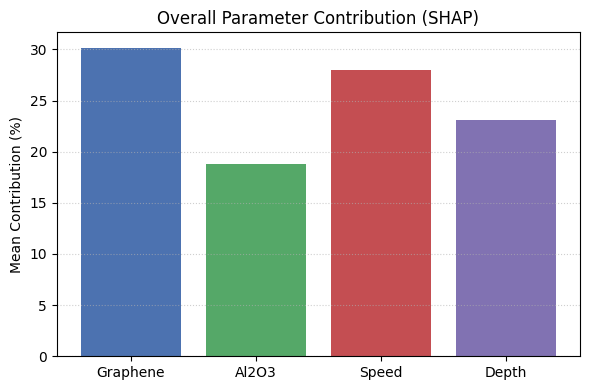

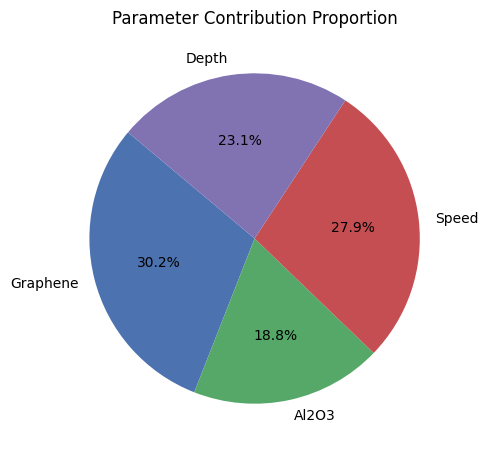

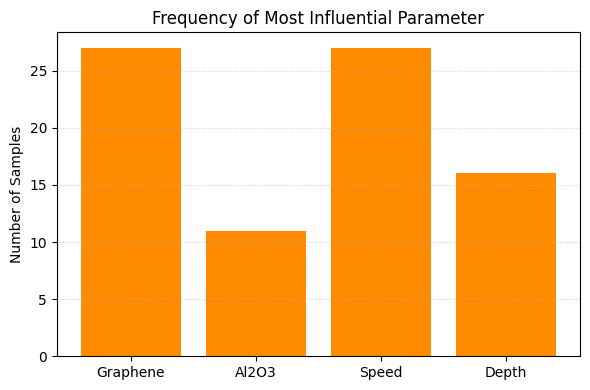

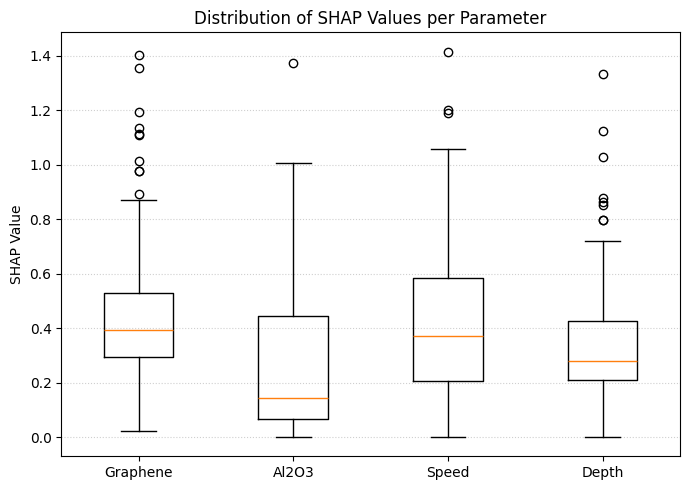

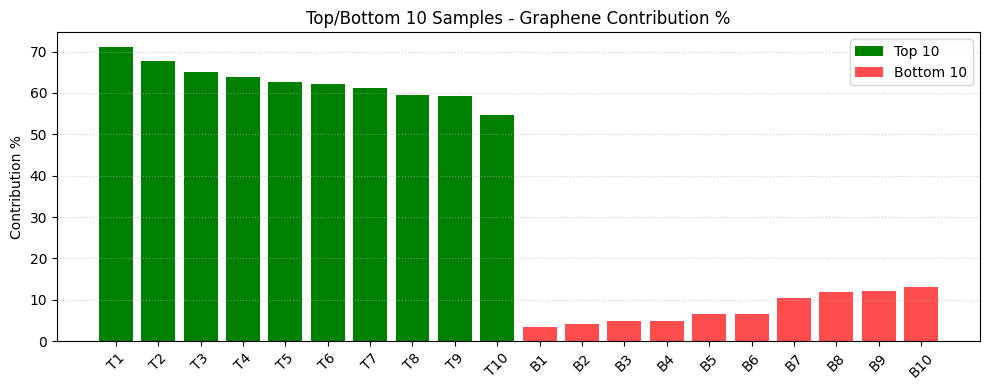

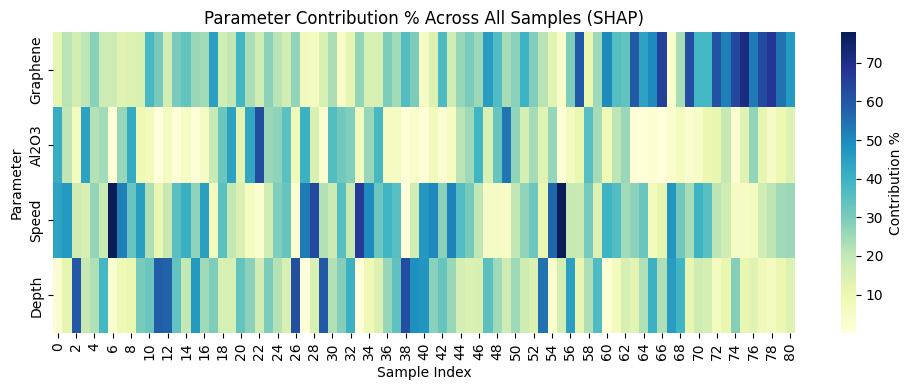

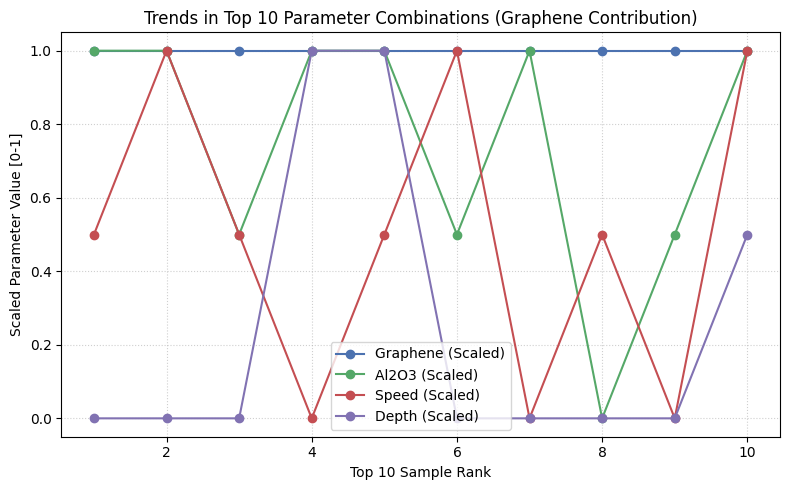

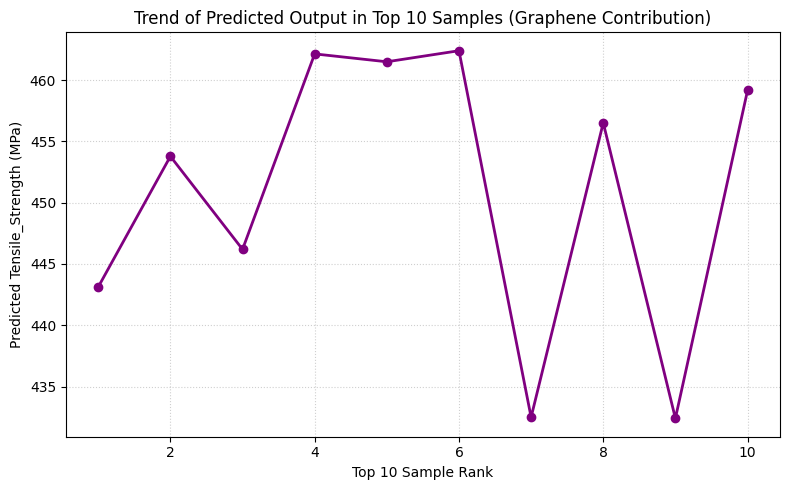

In [8]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. Falling back to variance estimation.")

# ==========================================
# 1. Load Original Data
# ==========================================
data = {
    "Exp": list(range(1, 26)),
    "Graphene": [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    "Al2O3": [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    "Speed": [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    "Depth": [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    "Tensile_Strength": [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

inputs = ["Graphene", "Al2O3", "Speed", "Depth"]
outputs = ["Tensile_Strength"]
outvar = outputs[0]

# ==========================================
# 2. Generate Synthetic Data Grid
# ==========================================
GRID_RESOLUTION = 3  # 3^4 = 81 points across 4 input features
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_RESOLUTION) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing="ij")
synthetic_df = pd.DataFrame({col: mesh[i].ravel() for i, col in enumerate(inputs)})

# Multi-dimensional RBF Interpolation for target parameter
rbf_scaler = StandardScaler()
X_orig_rbf = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_rbf = rbf_scaler.transform(synthetic_df[inputs].values)

rbf = RBFInterpolator(X_orig_rbf, df_orig[outvar].values, kernel="multiquadric", epsilon=1.0, smoothing=0.1)
synthetic_df[outvar] = rbf(X_synth_rbf)

# ==========================================
# 3. Combine Original + Synthetic Data for ML
# ==========================================
data_all = pd.concat([df_orig[inputs + outputs], synthetic_df[inputs + outputs]], ignore_index=True)
X_all = data_all[inputs].values
scalerX = StandardScaler().fit(X_all)
synthetic_scaled = scalerX.transform(synthetic_df[inputs].values)

# ==========================================
# 4. Fit Gaussian Process Regressor (GPR)
# ==========================================
scalerY = StandardScaler().fit(data_all[[outvar]].values)
y_all_scaled = scalerY.transform(data_all[[outvar]].values).flatten()

gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=gpr_kernel, alpha=1e-2, normalize_y=False, n_restarts_optimizer=0, random_state=42)
gpr.fit(scalerX.transform(data_all[inputs].values), y_all_scaled)

synthetic_df["GPR_pred"] = scalerY.inverse_transform(
    gpr.predict(synthetic_scaled).reshape(-1, 1)
).flatten()

# ==========================================
# 5. Parameter Contribution Analysis (SHAP)
# ==========================================
if HAS_SHAP:
    bg_summary = shap.kmeans(scalerX.transform(df_orig[inputs].values), 3)
    explainer = shap.KernelExplainer(gpr.predict, bg_summary)
    shap_matrix_raw = explainer.shap_values(synthetic_scaled, nsamples=100)
    shap_vals_matrix = np.abs(shap_matrix_raw)
else:
    shap_vals_matrix = np.abs(synthetic_scaled)

mean_abs_shap = shap_vals_matrix.mean(axis=0)
param_contrib_pct = 100 * mean_abs_shap / mean_abs_shap.sum()
param_contrib_dict = dict(zip(inputs, param_contrib_pct))

print("\nPARAMETER CONTRIBUTION ANALYSIS")
print("=" * 40)
print("Parameter Contribution (SHAP mean %):")
for param, pct in param_contrib_dict.items():
    print(f"  {param:<10}: {pct:.2f}%")

most_influential_param = max(param_contrib_dict, key=param_contrib_dict.get)
print(f"\nMost influential parameter: {most_influential_param} with {param_contrib_dict[most_influential_param]:.2f}% contribution\n")

# ==========================================
# 6. Frequency of Most Influential Parameter
# ==========================================
sample_most_influential_idx = np.argmax(shap_vals_matrix, axis=1)
param_names = np.array(inputs)
counts = pd.Series(param_names[sample_most_influential_idx]).value_counts()

print("Frequency of parameters being most influential across all synthetic samples:")
for param in param_names:
    freq = counts.get(param, 0)
    pct = 100 * freq / len(synthetic_df)
    print(f"  {param:<10}: {freq} samples ({pct:.2f}%)")

# ==========================================
# 7. Top/Bottom 10 Synthetic Samples
# ==========================================
most_inf_idx = inputs.index(most_influential_param)
total_sample_impact = shap_vals_matrix.sum(axis=1)
total_sample_impact = np.where(total_sample_impact == 0, 1e-9, total_sample_impact)

shap_param_pct = 100 * shap_vals_matrix[:, most_inf_idx] / total_sample_impact
synthetic_df[f"Contribution_%_{most_influential_param}"] = shap_param_pct
synthetic_df["Most_Influential_Parameter"] = param_names[sample_most_influential_idx]

top10 = synthetic_df.sort_values(f"Contribution_%_{most_influential_param}", ascending=False).head(10)
bottom10 = synthetic_df.sort_values(f"Contribution_%_{most_influential_param}", ascending=True).head(10)

print(f"\nTop 10 samples with highest % contribution from {most_influential_param}")
print(top10[inputs + ["GPR_pred", f"Contribution_%_{most_influential_param}", "Most_Influential_Parameter"]].to_string(index=False))

print(f"\nBottom 10 samples with lowest % contribution from {most_influential_param}")
print(bottom10[inputs + ["GPR_pred", f"Contribution_%_{most_influential_param}", "Most_Influential_Parameter"]].to_string(index=False))

# ==========================================
# 8. Most Common Parameter Values
# ==========================================
print("\nMOST COMMON PARAMETER VALUES IN SYNTHETIC DATA")
for param in inputs:
    value_counts = synthetic_df[param].value_counts()
    most_common = value_counts.idxmax()
    freq = value_counts.max()
    pct = 100 * freq / len(synthetic_df)
    print(f"  {param}: most common value = {most_common} (occurs {freq} times, {pct:.2f}% of samples)")
    print(f"  Other frequent values: {value_counts.head(3).to_dict()}")

# ==========================================
# 9. Unique Combinations & Frequencies
# ==========================================
comb_counts = synthetic_df.groupby(inputs).size().reset_index(name="Count").sort_values("Count", ascending=False)
print("\nTOP 5 MOST COMMON PARAMETER COMBINATIONS:")
print(comb_counts.head(5).to_string(index=False))

# ==========================================
# 10. Summary Statistics for Journal Reporting
# ==========================================
print("\nPARAMETER STATISTICS IN SYNTHETIC DATA (for journal):")
for param in inputs:
    print(f"{param}: min={synthetic_df[param].min():.4f}, max={synthetic_df[param].max():.4f}, mean={synthetic_df[param].mean():.4f}, std={synthetic_df[param].std():.4f}")

# ==========================================
# 11. Trends in Top 10 Combinations
# ==========================================
print(f"\nTRENDS IN TOP 10 PARAMETER COMBINATIONS (Highest Contribution % from {most_influential_param})")
print(top10[inputs + ["GPR_pred", f"Contribution_%_{most_influential_param}", "Most_Influential_Parameter"]].to_string(index=False))

# ==========================================
# PLOTS SECTION
# ==========================================
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# 1. Bar Plot: Overall Parameter Contribution (%)
plt.figure(figsize=(6, 4))
plt.bar(param_contrib_dict.keys(), param_contrib_dict.values(), color=colors[:len(inputs)])
plt.ylabel("Mean Contribution (%)")
plt.title("Overall Parameter Contribution (SHAP)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Pie Chart: Parameter Contribution (%)
plt.figure(figsize=(5, 5))
plt.pie(param_contrib_dict.values(), labels=param_contrib_dict.keys(), autopct="%1.1f%%", startangle=140, colors=colors[:len(inputs)])
plt.title("Parameter Contribution Proportion")
plt.tight_layout()
plt.show()

# 3. Bar Plot: Frequency Most Influential Parameter
plt.figure(figsize=(6, 4))
plot_counts = [counts.get(p, 0) for p in inputs]
plt.bar(inputs, plot_counts, color="darkorange")
plt.ylabel("Number of Samples")
plt.title("Frequency of Most Influential Parameter")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Boxplot: Distribution of SHAP Values (by parameter)
plt.figure(figsize=(7, 5))
data_boxplot = [shap_vals_matrix[:, i] for i in range(len(inputs))]
plt.boxplot(data_boxplot, tick_labels=inputs)
plt.ylabel("SHAP Value")
plt.title("Distribution of SHAP Values per Parameter")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Bar Plot: Top 10 vs Bottom 10 Samples (Contribution %)
plt.figure(figsize=(10, 4))
plt.bar(range(10), top10[f"Contribution_%_{most_influential_param}"], color="green", label="Top 10")
plt.bar(range(10, 20), bottom10[f"Contribution_%_{most_influential_param}"], color="red", alpha=0.7, label="Bottom 10")
plt.xticks(list(range(20)), [f"T{i+1}" for i in range(10)] + [f"B{i-9}" for i in range(10, 20)], rotation=45)
plt.ylabel("Contribution %")
plt.title(f"Top/Bottom 10 Samples - {most_influential_param} Contribution %")
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Heatmap: Contribution % for all samples
contrib_df = pd.DataFrame(shap_vals_matrix, columns=inputs)
contrib_pct_df = contrib_df.div(contrib_df.sum(axis=1).replace(0, 1e-9), axis=0) * 100

plt.figure(figsize=(10, 4))
sns.heatmap(contrib_pct_df.T, cmap="YlGnBu", cbar_kws={"label": "Contribution %"})
plt.xlabel("Sample Index")
plt.ylabel("Parameter")
plt.title("Parameter Contribution % Across All Samples (SHAP)")
plt.tight_layout()
plt.show()

# 7. Trends in Top 10 Parameter Combinations (Inputs)
plt.figure(figsize=(8, 5))
for i, param in enumerate(inputs):
    # Normalize values to a 0-1 scale so features with different units (e.g. Speed 600 vs Depth 0.25) can be compared on one plot
    min_val, max_val = df_orig[param].min(), df_orig[param].max()
    norm_vals = (top10[param] - min_val) / (max_val - min_val) if max_val > min_val else top10[param]
    plt.plot(range(1, 11), norm_vals, marker="o", label=f"{param} (Scaled)", color=colors[i])

plt.xlabel("Top 10 Sample Rank")
plt.ylabel("Scaled Parameter Value [0-1]")
plt.title(f"Trends in Top 10 Parameter Combinations ({most_influential_param} Contribution)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 8. Trend of Predicted Output in Top 10 Samples
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), top10["GPR_pred"], marker="o", color="purple", linewidth=2)
plt.xlabel("Top 10 Sample Rank")
plt.ylabel(f"Predicted {outvar} (MPa)")
plt.title(f"Trend of Predicted Output in Top 10 Samples ({most_influential_param} Contribution)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. Installing shap recommended for exact contribution analysis.")

# ==========================================
# 1. Load Data
# ==========================================
data = {
    'Exp': list(range(1, 26)),
    'Graphene': [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    'Al2O3': [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    'Speed': [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    'Depth': [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    'Tensile_Strength': [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

inputs = ['Graphene', 'Al2O3', 'Speed', 'Depth']
outputs = ['Tensile_Strength']

# ==========================================
# 2. Generate Synthetic Data Grid
# ==========================================
# Creating resolution grid for 4 input variables (3^4 = 81 synthetic grid combinations)
GRID_STEPS = 3
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_STEPS) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing='ij')

synthetic_df = pd.DataFrame({
    col: mesh[i].ravel() for i, col in enumerate(inputs)
})

# ==========================================
# 3. Interpolate Synthetic Outputs
# ==========================================
rbf_scaler = StandardScaler()
X_orig_scaled = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_scaled = rbf_scaler.transform(synthetic_df[inputs].values)

for col in outputs:
    rbf = RBFInterpolator(X_orig_scaled, df_orig[col].values, kernel='multiquadric', epsilon=1.0, smoothing=0.1)
    synthetic_df[col] = rbf(X_synth_scaled)

# ==========================================
# 4. Combine Original + Synthetic for ML
# ==========================================
data_all = pd.concat([df_orig[inputs + outputs], synthetic_df[inputs + outputs]], ignore_index=True)
X_all = data_all[inputs].values
scalerX = StandardScaler().fit(X_all)
synthetic_scaled = scalerX.transform(synthetic_df[inputs].values)

# ==========================================
# 5. Fit GPR, Run SHAP, & Find Optimal Params
# ==========================================
for outvar in outputs:
    print(f"\n{'='*55}\nOPTIMAL PARAMETER ANALYSIS FOR: {outvar}\n{'='*55}")

    scalerY = StandardScaler().fit(data_all[[outvar]].values)
    y_all = data_all[[outvar]].values
    y_all_scaled = scalerY.transform(y_all).flatten()

    # Fit Gaussian Process Regressor
    gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
    gpr = GaussianProcessRegressor(kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2, random_state=42)
    gpr.fit(scalerX.transform(data_all[inputs].values), y_all_scaled)

    synthetic_df[f'GPR_pred_{outvar}'] = scalerY.inverse_transform(
        gpr.predict(synthetic_scaled).reshape(-1, 1)
    ).flatten()

    # Calculate SHAP Values
    if HAS_SHAP:
        bg_summary = shap.kmeans(scalerX.transform(df_orig[inputs].values), 3)
        explainer = shap.KernelExplainer(gpr.predict, bg_summary)
        shap_vals_matrix = np.abs(explainer.shap_values(synthetic_scaled, nsamples=100))
    else:
        shap_vals_matrix = np.abs(synthetic_scaled)

    mean_abs_shap = shap_vals_matrix.mean(axis=0)
    param_contrib_pct = 100 * mean_abs_shap / mean_abs_shap.sum()
    param_contrib_dict = dict(zip(inputs, param_contrib_pct))

    print("Parameter Contribution (SHAP mean %):")
    for param, pct in param_contrib_dict.items():
        print(f"  {param:<10}: {pct:.2f}%")

    most_influential_param = max(param_contrib_dict, key=param_contrib_dict.get)
    print(f"\nMost influential parameter: {most_influential_param} with {param_contrib_dict[most_influential_param]:.2f}% contribution")

    sample_contrib = shap_vals_matrix
    sample_most_influential = np.argmax(sample_contrib, axis=1)
    param_names = np.array(inputs)
    counts = pd.Series(param_names[sample_most_influential]).value_counts()

    print("\nFrequency of parameters being most influential across all synthetic samples:")
    for param in param_names:
        freq = counts.get(param, 0)
        pct = 100 * freq / len(synthetic_df)
        print(f"  {param:<10}: {freq} samples ({pct:.2f}%)")

    total_sample_impact = sample_contrib.sum(axis=1)
    total_sample_impact = np.where(total_sample_impact == 0, 1e-9, total_sample_impact)

    most_inf_idx = inputs.index(most_influential_param)
    shap_param_pct = 100 * sample_contrib[:, most_inf_idx] / total_sample_impact
    synthetic_df['Contribution_%_' + most_influential_param] = shap_param_pct
    synthetic_df['Most_Influential_Parameter'] = param_names[sample_most_influential]

    # --- OPTIMAL PARAMETER IDENTIFICATION ---
    idx_max = synthetic_df[f'GPR_pred_{outvar}'].idxmax()
    optimal_row = synthetic_df.loc[idx_max, inputs + [f'GPR_pred_{outvar}']]

    print("\nOPTIMAL PARAMETER IDENTIFICATION:")
    print("Inputs for maximum predicted Tensile Strength:")
    for param in inputs:
        print(f"  {param:<10}: {optimal_row[param]}")
    print(f"Maximum predicted {outvar}: {optimal_row[f'GPR_pred_{outvar}']:.2f} MPa")

    # Top/Bottom 10 Samples Ranked by Contribution
    top10 = synthetic_df.sort_values('Contribution_%_' + most_influential_param, ascending=False).head(10)
    bottom10 = synthetic_df.sort_values('Contribution_%_' + most_influential_param, ascending=True).head(10)

    print(f"\nTop 10 samples with highest % contribution from {most_influential_param}:")
    print(top10[inputs + [f'GPR_pred_{outvar}', 'Contribution_%_' + most_influential_param, 'Most_Influential_Parameter']].to_string(index=False))

    print(f"\nBottom 10 samples with lowest % contribution from {most_influential_param}:")
    print(bottom10[inputs + [f'GPR_pred_{outvar}', 'Contribution_%_' + most_influential_param, 'Most_Influential_Parameter']].to_string(index=False))

    # Save to CSV files
    optimal_row.to_frame().T.to_csv(f'optimal_params_{outvar}.csv', index=False)
    top10.to_csv(f'top10_contribution_{outvar}.csv', index=False)

print("\nAll optimal parameters and top sample analyses saved to CSV successfully.")


OPTIMAL PARAMETER ANALYSIS FOR: Tensile_Strength


  0%|          | 0/81 [00:00<?, ?it/s]

Parameter Contribution (SHAP mean %):
  Graphene  : 29.02%
  Al2O3     : 17.27%
  Speed     : 31.52%
  Depth     : 22.18%

Most influential parameter: Speed with 31.52% contribution

Frequency of parameters being most influential across all synthetic samples:
  Graphene  : 30 samples (37.04%)
  Al2O3     : 9 samples (11.11%)
  Speed     : 27 samples (33.33%)
  Depth     : 15 samples (18.52%)

OPTIMAL PARAMETER IDENTIFICATION:
Inputs for maximum predicted Tensile Strength:
  Graphene  : 0.03
  Al2O3     : 0.1
  Speed     : 1800.0
  Depth     : 1.25
Maximum predicted Tensile_Strength: 579.29 MPa

Top 10 samples with highest % contribution from Speed:
 Graphene  Al2O3  Speed  Depth  GPR_pred_Tensile_Strength  Contribution_%_Speed Most_Influential_Parameter
     0.09   0.14 1200.0   1.25                 468.289340             68.718982                      Speed
     0.03   0.14  600.0   0.75                 479.512796             67.723993                      Speed
     0.15   0.14 1200.

In [11]:
import warnings
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. Installing shap recommended for exact contribution analysis.")

# ==========================================
# Inputs & Original Data
# ==========================================
inputs = ['Graphene', 'Al2O3', 'Speed', 'Depth']

data = {
    'Exp': list(range(1, 26)),
    'Graphene': [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    'Al2O3': [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
    'Speed': [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
    'Depth': [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
    'Tensile_Strength': [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
}
df_orig = pd.DataFrame(data)

output_targets = [
    ("Tensile_Strength", "Tensile_Strength"),
]

# ==========================================
# 1. Generate Synthetic Data Grid
# ==========================================
GRID_STEPS = 3  # 3^4 = 81 synthetic grid combinations
grid_axes = [np.linspace(df_orig[col].min(), df_orig[col].max(), GRID_STEPS) for col in inputs]
mesh = np.meshgrid(*grid_axes, indexing='ij')

synthetic_df = pd.DataFrame({
    col: mesh[i].ravel() for i, col in enumerate(inputs)
})

# ==========================================
# 2. Interpolate Synthetic Outputs (Using RBFInterpolator)
# ==========================================
rbf_scaler = StandardScaler()
X_orig_scaled = rbf_scaler.fit_transform(df_orig[inputs].values)
X_synth_scaled = rbf_scaler.transform(synthetic_df[inputs].values)

for _, col in output_targets:
    rbf = RBFInterpolator(X_orig_scaled, df_orig[col].values, kernel='multiquadric', epsilon=1.0, smoothing=0.1)
    synthetic_df[col] = rbf(X_synth_scaled)

# ==========================================
# 3. Prepare Data and Scaling for ML
# ==========================================
data_all = pd.concat([df_orig[inputs + [col for _, col in output_targets]],
                     synthetic_df[inputs + [col for _, col in output_targets]]],
                    ignore_index=True)

X_all = data_all[inputs].values
scalerX = StandardScaler().fit(X_all)
synthetic_scaled = scalerX.transform(synthetic_df[inputs].values)

# ==========================================
# 4. GPR, Predict, SHAP Contributions, & Table Generation
# ==========================================
for table_name, outvar in output_targets:
    scalerY = StandardScaler().fit(data_all[[outvar]].values)
    y_all_scaled = scalerY.transform(data_all[[outvar]].values).flatten()

    # Fit Gaussian Process Regressor
    gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
    gpr = GaussianProcessRegressor(kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2, random_state=42)
    gpr.fit(scalerX.transform(data_all[inputs].values), y_all_scaled)

    synthetic_df[f'GPR_pred_{outvar}'] = scalerY.inverse_transform(
        gpr.predict(synthetic_scaled).reshape(-1, 1)
    ).flatten()

    # Calculate SHAP values
    if HAS_SHAP:
        bg_summary = shap.kmeans(scalerX.transform(df_orig[inputs].values), 3)
        explainer = shap.KernelExplainer(gpr.predict, bg_summary)
        raw_shap_matrix = explainer.shap_values(synthetic_scaled, nsamples=100)
        shap_vals_matrix = np.abs(raw_shap_matrix)
    else:
        shap_vals_matrix = np.abs(synthetic_scaled)

    total_impact = shap_vals_matrix.sum(axis=1, keepdims=True)
    total_impact = np.where(total_impact == 0, 1e-9, total_impact)
    param_contrib_pct = 100 * shap_vals_matrix / total_impact

    # Add contribution percentages and identify most influential parameter
    for i, param in enumerate(inputs):
        synthetic_df[f'Contribution % {param}_{outvar}'] = param_contrib_pct[:, i]

    synthetic_df[f'Most Influential Parameter_{outvar}'] = [
        inputs[idx] for idx in np.argmax(param_contrib_pct, axis=1)
    ]

    # Strength Rank (1 = highest contribution strength in the sample)
    synthetic_df[f'Strength Rank_{outvar}'] = synthetic_df[
        [f'Contribution % {param}_{outvar}' for param in inputs]
    ].max(axis=1).rank(ascending=False, method='min')

    # Print Table Summary
    print(f"\nSynthetic Data Table for {table_name} (GPR, SHAP Contributions & Strength Rank):")
    print("-" * 100)

    cols = inputs + [outvar, f'GPR_pred_{outvar}', f'Strength Rank_{outvar}'] + \
           [f'Contribution % {param}_{outvar}' for param in inputs] + \
           [f'Most Influential Parameter_{outvar}']

    pretty_cols = inputs + [
        outvar, 'GPR_pred', 'Strength_Rank',
        'Contribution_%_Graphene', 'Contribution_%_Al2O3', 'Contribution_%_Speed', 'Contribution_%_Depth',
        'Most_Influential_Parameter'
    ]

    table = synthetic_df[cols].copy()
    table.columns = pretty_cols
    print(table.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

# ==========================================
# 5. Save to CSV
# ==========================================
for table_name, outvar in output_targets:
    cols = inputs + [outvar, f'GPR_pred_{outvar}', f'Strength Rank_{outvar}'] + \
           [f'Contribution % {param}_{outvar}' for param in inputs] + \
           [f'Most Influential Parameter_{outvar}']

    table = synthetic_df[cols].copy()
    table.columns = inputs + [
        outvar, 'GPR_pred', 'Strength_Rank',
        'Contribution_%_Graphene', 'Contribution_%_Al2O3', 'Contribution_%_Speed', 'Contribution_%_Depth',
        'Most_Influential_Parameter'
    ]

    csv_filename = f"synthetic_GPR_contribution_{outvar}.csv"
    table.to_csv(csv_filename, index=False)
    print(f"\nSynthetic GPR contribution table saved to '{csv_filename}'.")

  0%|          | 0/81 [00:00<?, ?it/s]


Synthetic Data Table for Tensile_Strength (GPR, SHAP Contributions & Strength Rank):
----------------------------------------------------------------------------------------------------
 Graphene    Al2O3    Speed    Depth  Tensile_Strength  GPR_pred  Strength_Rank  Contribution_%_Graphene  Contribution_%_Al2O3  Contribution_%_Speed  Contribution_%_Depth Most_Influential_Parameter
     0.03     0.10   600.00     0.25            409.44    409.44          44.00                     5.11                 31.72                 45.70                 17.47                      Speed
     0.03     0.10   600.00     0.75            443.67    443.67          12.00                     8.95                 16.59                 56.27                 18.19                      Speed
     0.03     0.10   600.00     1.25            533.31    533.31          42.00                    46.12                  8.75                  4.61                 40.51                   Graphene
     0.03     0.10  1

In [15]:
import warnings
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF as GPR_RBF
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: 'shap' library not found. Install via 'pip install shap' for exact SHAP values.")


def run_gpr_shap_analysis(
    df: pd.DataFrame,
    input_cols: list[str],
    output_cols: list[str],
    grid_steps: int = 3,
    output_prefix: str = "dataset"
) -> dict[str, pd.DataFrame]:

    processed_results = {}

    for outvar in output_cols:
        print(f"\n==================================================================")
        print(f" ANALYSIS FOR OUTPUT: {outvar}")
        print(f"==================================================================")

        # 1. Generate Synthetic Grid
        grid_axes = [np.linspace(df[col].min(), df[col].max(), grid_steps) for col in input_cols]
        mesh = np.meshgrid(*grid_axes, indexing='ij')

        synthetic_df = pd.DataFrame({
            col: mesh[i].ravel() for i, col in enumerate(input_cols)
        })

        # 2. RBF Interpolation
        rbf_scaler = StandardScaler()
        X_orig_scaled = rbf_scaler.fit_transform(df[input_cols].values)
        X_synth_scaled = rbf_scaler.transform(synthetic_df[input_cols].values)

        rbf = RBFInterpolator(X_orig_scaled, df[outvar].values, kernel='multiquadric', epsilon=1.0, smoothing=0.1)
        synthetic_df[outvar] = rbf(X_synth_scaled)

        # 3. GPR Model
        data_all = pd.concat([df[input_cols + [outvar]], synthetic_df[input_cols + [outvar]]], ignore_index=True)
        scalerX = StandardScaler().fit(data_all[input_cols].values)
        synthetic_scaled = scalerX.transform(synthetic_df[input_cols].values)

        scalerY = StandardScaler().fit(data_all[[outvar]].values)
        y_all_scaled = scalerY.transform(data_all[[outvar]].values).flatten()

        gpr_kernel = C(1.0) * GPR_RBF(length_scale=1.0)
        gpr = GaussianProcessRegressor(kernel=gpr_kernel, normalize_y=True, n_restarts_optimizer=2, random_state=42)
        gpr.fit(scalerX.transform(data_all[input_cols].values), y_all_scaled)

        synthetic_df[f'GPR_pred_{outvar}'] = scalerY.inverse_transform(
            gpr.predict(synthetic_scaled).reshape(-1, 1)
        ).flatten()

        # 4. SHAP Values
        if HAS_SHAP:
            bg_summary = shap.kmeans(scalerX.transform(df[input_cols].values), min(3, len(df)))
            explainer = shap.KernelExplainer(gpr.predict, bg_summary)
            raw_shap = explainer.shap_values(synthetic_scaled, nsamples=100)
            shap_matrix = np.abs(raw_shap)
        else:
            shap_matrix = np.abs(synthetic_scaled)

        total_impact = shap_matrix.sum(axis=1, keepdims=True)
        total_impact = np.where(total_impact == 0, 1e-9, total_impact)
        param_contrib_pct = 100 * shap_matrix / total_impact

        # Add contribution columns
        for i, param in enumerate(input_cols):
            synthetic_df[f'Contrib_%_{param}'] = param_contrib_pct[:, i]

        synthetic_df['Most_Influential_Parameter'] = [
            input_cols[idx] for idx in np.argmax(param_contrib_pct, axis=1)
        ]

        synthetic_df['Strength_Rank'] = synthetic_df[
            [f'Contrib_%_{param}' for param in input_cols]
        ].max(axis=1).rank(ascending=False, method='min')

        # --------------------------------------------------
        # PRINT RESULTS DIRECTLY TO TERMINAL
        # --------------------------------------------------
        # Overall Parameter Importance
        mean_contribs = param_contrib_pct.mean(axis=0)
        print("\n--- OVERALL PARAMETER CONTRIBUTION (SHAP Mean %) ---")
        for param, pct in zip(input_cols, mean_contribs):
            print(f"  {param:<12}: {pct:.2f}%")

        # Optimal Parameters
        idx_max = synthetic_df[f'GPR_pred_{outvar}'].idxmax()
        optimal_row = synthetic_df.loc[idx_max]

        print(f"\n--- OPTIMAL PARAMETERS FOR MAXIMUM {outvar.upper()} ---")
        for param in input_cols:
            print(f"  {param:<12}: {optimal_row[param]}")
        print(f"  Max Predicted {outvar}: {optimal_row[f'GPR_pred_{outvar}']:.2f}")

        # Display Top 5 Samples
        display_cols = input_cols + [f'GPR_pred_{outvar}', 'Strength_Rank', 'Most_Influential_Parameter']
        print("\n--- TOP 5 SAMPLES (HIGHEST STRENGTH RANK) ---")
        print(synthetic_df.sort_values('Strength_Rank').head(5)[display_cols].to_string(index=False))

        # Save to CSV
        csv_filename = f"{output_prefix}_{outvar}_results.csv"
        synthetic_df.to_csv(csv_filename, index=False)
        print(f"\n[+] Full table ({len(synthetic_df)} rows) saved to: '{csv_filename}'")

        processed_results[outvar] = synthetic_df

    return processed_results


# ==========================================
# RUN THE SCRIPT
# ==========================================
if __name__ == "__main__":
    # Your Dataset
    df = pd.DataFrame({
        'Graphene': [0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.15, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
        'Al2O3': [0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18, 0.1, 0.12, 0.14, 0.16, 0.18],
        'Speed': [600, 900, 1200, 1500, 1800, 900, 1200, 1500, 1800, 600, 1200, 1500, 1800, 600, 900, 1500, 1800, 600, 900, 1200, 1800, 600, 900, 1200, 1500],
        'Depth': [0.25, 0.5, 0.75, 1.0, 1.25, 0.75, 1.0, 1.25, 0.25, 0.5, 1.25, 0.25, 0.75, 0.5, 1.0, 0.5, 0.75, 1.0, 1.25, 0.25, 1.0, 1.25, 0.25, 0.5, 0.75],
        'Tensile_Strength': [385, 402, 415, 424, 435, 452, 468, 473, 480, 455, 500, 504, 510, 495, 498, 535, 538, 516, 522, 525, 590, 535, 554, 566, 578]
    })

    # Execute
    results = run_gpr_shap_analysis(
        df=df,
        input_cols=['Graphene', 'Al2O3', 'Speed', 'Depth'],
        output_cols=['Tensile_Strength'],
        grid_steps=3,
        output_prefix="materials"
    )


 ANALYSIS FOR OUTPUT: Tensile_Strength


  0%|          | 0/81 [00:00<?, ?it/s]


--- OVERALL PARAMETER CONTRIBUTION (SHAP Mean %) ---
  Graphene    : 29.12%
  Al2O3       : 16.19%
  Speed       : 31.04%
  Depth       : 23.66%

--- OPTIMAL PARAMETERS FOR MAXIMUM TENSILE_STRENGTH ---
  Graphene    : 0.03
  Al2O3       : 0.1
  Speed       : 1800.0
  Depth       : 1.25
  Max Predicted Tensile_Strength: 579.29

--- TOP 5 SAMPLES (HIGHEST STRENGTH RANK) ---
 Graphene  Al2O3  Speed  Depth  GPR_pred_Tensile_Strength  Strength_Rank Most_Influential_Parameter
     0.09   0.18 1800.0   0.25                 498.086298            1.0                      Depth
     0.09   0.14 1800.0   0.25                 496.754195            2.0                      Depth
     0.09   0.14  600.0   1.25                 495.713979            3.0                      Depth
     0.09   0.14 1200.0   1.25                 468.289340            4.0                      Speed
     0.03   0.14  600.0   0.75                 479.512796            5.0                      Speed

[+] Full table (81 rows